In [196]:
# REVISIONS 
# 1. pivoting and dropping of duplicated as been carried out prior to the data cleaning
# 2. Normalisation of all the unknown values to 'unkwn' has been carried out first in the data cleaning part
# 3. The first letters of geographical location values are capitalised and cases like usa have been changed to USA (manual dictionary)
# 4. commented the logic for the serotype normalisation
# 5. sequence length was converted to Mbp
# 6. The individual codes for assembly stats part are deleted
# 7. for different contig thresholds (200, 250, 300 an 500), the number of genomes lost and retained are represented as plots
# 8. serotype distribution (normalised) before and after the filtering has been plotted
# 9. For EDA, the scripts have been revised as functions
# 10. non-human samples and food samples have be renamed as others and used for renaming

"""
Rechecked - matches with the original script.
Minor changes made:
1. replaced 'Not Applicable' to unkwn as well 
   - since the normalisation was done later on for serotype columns specially, this did not affect the results
   - other columns that included the value was just used for annotation
2. Added Scaffold L50 and N50 as well for the plots (not included in the multipanel image)

"""

"\nRechecked - matches with the original script.\nMinor changes made:\n1. replaced 'Not Applicable' to unkwn as well \n   - since the normalisation was done later on for serotype columns specially, this did not affect the results\n   - other columns that included the value was just used for annotation\n2. Added Scaffold L50 and N50 as well for the plots (not included in the multipanel image)\n\n"

# Retrival of genomic data and metadata

# Library import

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

# Loading metadata

In [6]:
pd.set_option("display.max_columns", 180)
raw = pd.read_excel("/media/dell/My Passport/vc_files_v_final/1_v_cholerae_refseq.xlsx")
print(f'rows: ',raw.shape[0],f'\ncolumns: ',raw.shape[1])
raw.head()

rows:  19569 
columns:  178


,Assembly Accession,ANI Best ANI match ANI,ANI Best ANI match Assembly,ANI Best ANI match Assembly Coverage,ANI Best ANI match Type Category,ANI Best ANI match Organism,ANI Best ANI match Type Assembly Coverage,ANI Best match status,ANI Category,ANI Check status,ANI Comment,ANI Declared ANI match ANI,ANI Declared ANI match Assembly,ANI Declared ANI match Assembly Coverage,ANI Declared ANI match Type Category,ANI Declared ANI match Organism,ANI Declared ANI match Type Assembly Coverage,ANI Submitted organism,ANI Submitted species,Annotation BUSCO Complete,Annotation BUSCO Duplicated,Annotation BUSCO Fragmented,Annotation BUSCO Lineage,Annotation BUSCO Missing,Annotation BUSCO Single Copy,Annotation BUSCO Total Count,Annotation BUSCO Version,Annotation Count Gene Non-coding,Annotation Count Gene Other,Annotation Count Gene Protein-coding,Annotation Count Gene Pseudogene,Annotation Count Gene Total,Annotation Method,Annotation Name,Annotation Pipeline,Annotation Provider,Annotation Release Date,Annotation Report URL,Annotation Software Version,Annotation Status,Assembly Assembly Method,Assembly Atypical Is Atypical,Assembly Atypical Warnings,Assembly BioProject Accession,Assembly BioProject Lineage Accession,Assembly BioProject Lineage Parent Accession,Assembly BioProject Lineage Parent Accessions,Assembly BioProject Lineage Title,Assembly BioSample Accession,Assembly BioSample Age,Assembly BioSample Attribute Name,Assembly BioSample Attribute Value,Assembly BioSample Biomaterial provider,Assembly BioSample BioProject Accession,Assembly BioSample BioProject Parent Accession,Assembly BioSample BioProject Parent Accessions,Assembly BioSample BioProject Title,Assembly BioSample Breed,Assembly BioSample Collected by,Assembly BioSample Collection date,Assembly BioSample Cultivar,Assembly BioSample Description Comment,Assembly BioSample Description Organism Common Name,Assembly BioSample Description Organism Infraspecific Names Breed,Assembly BioSample Description Organism Infraspecific Names Cultivar,Assembly BioSample Description Organism Infraspecific Names Ecotype,Assembly BioSample Description Organism Infraspecific Names Isolate,Assembly BioSample Description Organism Infraspecific Names Sex,Assembly BioSample Description Organism Infraspecific Names Strain,Assembly BioSample Description Organism Name,Assembly BioSample Description Organism Pangolin Classification,Assembly BioSample Description Organism Taxonomic ID,Assembly BioSample Description Title,Assembly BioSample Development stage,Assembly BioSample Ecotype,Assembly BioSample Geographic location,Assembly BioSample Host,Assembly BioSample Host disease,Assembly BioSample Identified by,Assembly BioSample Sample Identifiers Database,Assembly BioSample Sample Identifiers Label,Assembly BioSample Sample Identifiers Value,Assembly BioSample IFSAC category,Assembly BioSample Isolate,Assembly BioSample Isolate name alias,Assembly BioSample Isolation source,Assembly BioSample Last updated,Assembly BioSample Latitude and Longitude,Assembly BioSample Models,Assembly BioSample Owner Contact Lab,Assembly BioSample Owner Name,Assembly BioSample Package,Assembly BioSample Project name,Assembly BioSample Publication date,Assembly BioSample Sample name,Assembly BioSample Serotype,Assembly BioSample Serovar,Assembly BioSample Sex,Assembly BioSample Source type,Assembly BioSample Status Status,Assembly BioSample Status When,Assembly BioSample Strain,Assembly BioSample Sub-species,Assembly BioSample Submission date,Assembly BioSample Tissue,Assembly Blast URL,Assembly Description,Assembly Diploid Role,Assembly Grouping Method,Assembly Level,Assembly Linked Assembly Accession,Assembly Linked Assembly Type,Assembly LongName,Assembly Name,Assembly Notes,Assembly Paired Assembly Accession,Assembly Paired Assembly Changed,Assembly Paired Assembly Differences,Assembly Paired Assembly Manual Diff,Assembly Paired Assembly Name,Assembly Paired Assembly Only Genbank,Assembly Paired Assembly Only RefSeq

In [76]:
#copy dataframe
df = raw.copy()

In [77]:
#check unique ids - total number of genomes
df["Assembly Accession"].nunique()

2040

In [78]:
len(df.columns)

178

In [79]:
#print columns
for i in range(len(df.columns)):
    print(i, df.columns[i])

0 Assembly Accession
1 ANI Best ANI match ANI
2 ANI Best ANI match Assembly
3 ANI Best ANI match Assembly Coverage
4 ANI Best ANI match Type Category
5 ANI Best ANI match Organism
6 ANI Best ANI match Type Assembly Coverage
7 ANI Best match status
8 ANI Category
9 ANI Check status
10 ANI Comment
11 ANI Declared ANI match ANI
12 ANI Declared ANI match Assembly
13 ANI Declared ANI match Assembly Coverage
14 ANI Declared ANI match Type Category
15 ANI Declared ANI match Organism
16 ANI Declared ANI match Type Assembly Coverage
17 ANI Submitted organism
18 ANI Submitted species
19 Annotation BUSCO Complete
20 Annotation BUSCO Duplicated
21 Annotation BUSCO Fragmented
22 Annotation BUSCO Lineage
23 Annotation BUSCO Missing
24 Annotation BUSCO Single Copy
25 Annotation BUSCO Total Count
26 Annotation BUSCO Version
27 Annotation Count Gene Non-coding
28 Annotation Count Gene Other
29 Annotation Count Gene Protein-coding
30 Annotation Count Gene Pseudogene
31 Annotation Count Gene Total
32 Ann

# Pivoting
### Required to obtain all the serotype and collection year info 

In [80]:
#biosample info
#Serogroup info is not provided in raw data columns. Hence, pivoting is required.
df1 = df.pivot_table(index=['Assembly BioSample Accession','Assembly Accession'],
                     columns='Assembly BioSample Attribute Name',
                     values='Assembly BioSample Attribute Value',
                     aggfunc='first')

wanted_attribute = ['collection_date','strain','isolation source','geo_loc_name','sample_type','lat_lon','serotype','serovar','serogroup']

df1 = df1.reindex(columns=wanted_attribute)
df1 = df1.reset_index()
print(df1.shape)
df1.head()

(2040, 11)


Assembly BioSample Attribute Name,Assembly BioSample Accession,Assembly Accession,collection_date,strain,isolation source,geo_loc_name,sample_type,lat_lon,serotype,serovar,serogroup
0,SAMD00061025,GCF_000829215.1,NaN,MS6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SAMD00118470,GCF_003574155.1,missing,V060002,NaN,missing,NaN,missing,NaN,NaN,NaN
2,SAMD00221480,GCF_014634265.1,1977-08-01,PS-7701,NaN,Japan:Shiga,NaN,missing,NaN,NaN,NaN
3,SAMD00221481,GCF_014634285.1,1977-08-01,PS-7702,NaN,Japan:Shiga,NaN,missing,NaN,NaN,NaN
4,SAMD00221482,GCF_014634305.1,1977-08-01,PS-7703,NaN,Japan:Shiga,NaN,missing,NaN,NaN,NaN


In [81]:
merg = pd.merge(df, df1, on='Assembly Accession', how='left')
merg.shape

(19569, 188)

In [82]:
# check - added pivoted columns

# Dropping duplicates

In [83]:
merg = merg.drop_duplicates(subset = "Assembly Accession", keep = "first")
print(merg.shape)  # number of genomes retained
merg.head(3)

(2040, 188)


,Assembly Accession,ANI Best ANI match ANI,ANI Best ANI match Assembly,ANI Best ANI match Assembly Coverage,ANI Best ANI match Type Category,ANI Best ANI match Organism,ANI Best ANI match Type Assembly Coverage,ANI Best match status,ANI Category,ANI Check status,ANI Comment,ANI Declared ANI match ANI,ANI Declared ANI match Assembly,ANI Declared ANI match Assembly Coverage,ANI Declared ANI match Type Category,ANI Declared ANI match Organism,ANI Declared ANI match Type Assembly Coverage,ANI Submitted organism,ANI Submitted species,Annotation BUSCO Complete,Annotation BUSCO Duplicated,Annotation BUSCO Fragmented,Annotation BUSCO Lineage,Annotation BUSCO Missing,Annotation BUSCO Single Copy,Annotation BUSCO Total Count,Annotation BUSCO Version,Annotation Count Gene Non-coding,Annotation Count Gene Other,Annotation Count Gene Protein-coding,Annotation Count Gene Pseudogene,Annotation Count Gene Total,Annotation Method,Annotation Name,Annotation Pipeline,Annotation Provider,Annotation Release Date,Annotation Report URL,Annotation Software Version,Annotation Status,Assembly Assembly Method,Assembly Atypical Is Atypical,Assembly Atypical Warnings,Assembly BioProject Accession,Assembly BioProject Lineage Accession,Assembly BioProject Lineage Parent Accession,Assembly BioProject Lineage Parent Accessions,Assembly BioProject Lineage Title,Assembly BioSample Accession_x,Assembly BioSample Age,Assembly BioSample Attribute Name,Assembly BioSample Attribute Value,Assembly BioSample Biomaterial provider,Assembly BioSample BioProject Accession,Assembly BioSample BioProject Parent Accession,Assembly BioSample BioProject Parent Accessions,Assembly BioSample BioProject Title,Assembly BioSample Breed,Assembly BioSample Collected by,Assembly BioSample Collection date,Assembly BioSample Cultivar,Assembly BioSample Description Comment,Assembly BioSample Description Organism Common Name,Assembly BioSample Description Organism Infraspecific Names Breed,Assembly BioSample Description Organism Infraspecific Names Cultivar,Assembly BioSample Description Organism Infraspecific Names Ecotype,Assembly BioSample Description Organism Infraspecific Names Isolate,Assembly BioSample Description Organism Infraspecific Names Sex,Assembly BioSample Description Organism Infraspecific Names Strain,Assembly BioSample Description Organism Name,Assembly BioSample Description Organism Pangolin Classification,Assembly BioSample Description Organism Taxonomic ID,Assembly BioSample Description Title,Assembly BioSample Development stage,Assembly BioSample Ecotype,Assembly BioSample Geographic location,Assembly BioSample Host,Assembly BioSample Host disease,Assembly BioSample Identified by,Assembly BioSample Sample Identifiers Database,Assembly BioSample Sample Identifiers Label,Assembly BioSample Sample Identifiers Value,Assembly BioSample IFSAC category,Assembly BioSample Isolate,Assembly BioSample Isolate name alias,Assembly BioSample Isolation source,Assembly BioSample Last updated,Assembly BioSample Latitude and Longitude,Assembly BioSample Models,Assembly BioSample Owner Contact Lab,...,Assembly BioSample Source type,Assembly BioSample Status Status,Assembly BioSample Status When,Assembly BioSample Strain,Assembly BioSample Sub-species,Assembly BioSample Submission date,Assembly BioSample Tissue,Assembly Blast URL,Assembly Description,Assembly Diploid Role,Assembly Grouping Method,Assembly Level,Assembly Linked Assembly Accession,Assembly Linked Assembly Type,Assembly LongName,Assembly Name,Assembly Notes,Assembly Paired Assembly Accession,Assembly Paired Assembly Changed,Assembly Paired Assembly Differences,Assembly Paired Assembly Manual Diff,Assembly Paired Assembly Name,Assembly Paired Assembly Only Genbank,Assembly Paired Assembly Only RefSeq,Assembly Paired Assembly RefSeq GenBank Are Different,Assembly Paired Assembly Status,Assembly Refseq Category,Assembly Release Date,Assembly Sequencing Tech,Assembly Status,Assembly Submitter,Assembly Suppression Reason,Assemb

In [84]:
# check - 2040 genome ids are retained

# Retaining necessary columns

In [85]:
wanted_columns = ['Assembly Accession',

                  # Assembly stats
                  'Annotation Count Gene Non-coding','Annotation Count Gene Protein-coding',
                  'Annotation Count Gene Pseudogene', 
                  'Annotation Count Gene Total','Assembly BioProject Accession',
                  'Assembly Stats ATGC Count','Assembly Stats Contig L50',
                  'Assembly Stats Contig N50','Assembly Stats GC Count',
                  'Assembly Stats GC Percent','Assembly Stats Genome Coverage',
                  'Assembly Stats Number of Component Sequences','Assembly Stats Number of Contigs',
                  'Assembly Stats Number of Scaffolds','Assembly Stats Total Sequence Length',
                  'CheckM completeness', 'CheckM contamination', 
                  'Assembly Stats Scaffold L50','Assembly Stats Scaffold N50',
 

                  # Bioproject and biosample details
                  'Assembly BioProject Lineage Accession','Assembly BioProject Lineage Title',
                  'Assembly BioSample Accession','Assembly BioSample BioProject Accession',

                  # genome characteristics
                  'Assembly BioSample Geographic location','Assembly BioSample Host',
                  'Assembly BioSample Host disease','Assembly BioSample Isolation source',
                  'Assembly BioSample Latitude and Longitude','Assembly Type',
                  'Assembly BioSample Serotype', 'Assembly BioSample Serovar',
                  'collection_date','Assembly Length', 'Assembly Level',  
                  # assembly level was included twice in the previous script, hence it has been included only once

                  # pivoted columns
                  'strain','isolation source','geo_loc_name', # serogroup_serotype column was included in the previous versions by mistake
                  'sample_type','lat_lon','serotype','serovar','serogroup','collection_year'
                  # serotype info is not complete in one column. hence, all the related columns are retained for further normalisation 
                 ]

columns_to_drop = []
for col in merg.columns:
    if col not in wanted_columns: # include only wanted columns
        columns_to_drop.append(col)

merg = merg.drop(columns=columns_to_drop)

print("CHANGES AFTER RETAINING THE NECESSARY COLUMNS")
print("Number of rows and columns:",merg.shape) 
print("Number of Unique values in the Assembly Accession column:",merg["Assembly Accession"].nunique(),"\n")
merg.head()

CHANGES AFTER RETAINING THE NECESSARY COLUMNS
Number of rows and columns: (2040, 41)
Number of Unique values in the Assembly Accession column: 2040 



,Assembly Accession,Annotation Count Gene Non-coding,Annotation Count Gene Protein-coding,Annotation Count Gene Pseudogene,Annotation Count Gene Total,Assembly BioProject Accession,Assembly BioProject Lineage Accession,Assembly BioProject Lineage Title,Assembly BioSample BioProject Accession,Assembly BioSample Geographic location,Assembly BioSample Host,Assembly BioSample Host disease,Assembly BioSample Isolation source,Assembly BioSample Latitude and Longitude,Assembly BioSample Serotype,Assembly BioSample Serovar,Assembly Level,Assembly Type,Assembly Stats ATGC Count,Assembly Stats Contig L50,Assembly Stats Contig N50,Assembly Stats GC Count,Assembly Stats GC Percent,Assembly Stats Genome Coverage,Assembly Stats Number of Component Sequences,Assembly Stats Number of Contigs,Assembly Stats Number of Scaffolds,Assembly Stats Scaffold L50,Assembly Stats Scaffold N50,Assembly Stats Total Sequence Length,CheckM completeness,CheckM contamination,collection_date,strain,isolation source,geo_loc_name,sample_type,lat_lon,serotype,serovar,serogroup
0,GCF_000736765.1,86,3371,100,3557,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,NaN,Diarrhea,NaN,NaN,NaN,Contig,haploid,3866097,12,116343,1847732,48.00,51.90,118,118,118,12,116343,3866097,98.41,1.23,1973,133-73,NaN,India,missing,NaN,NaN,NaN,O48
7,GCF_000736775.1,73,3431,71,3575,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,NaN,Diarrhea,NaN,NaN,NaN,Contig,haploid,3946950,9,145570,1883900,47.50,46.80,117,117,117,9,145570,3946950,98.29,1.16,1981,984-81,NaN,India,missing,NaN,NaN,NaN,O89
14,GCF_000736785.1,72,3453,94,3619,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,NaN,Diarrhea,NaN,NaN,NaN,Contig,haploid,3969137,10,153084,1881066,47.50,26.90,118,118,118,10,153084,3969137,98.14,1.28,1977,1421-77,NaN,India,missing,NaN,NaN,NaN,O80
21,GCF_000736795.1,70,3348,114,3532,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,Philippines,Homo sapiens,NaN,Diarrhea,NaN,NaN,NaN,Contig,haploid,3913714,9,154399,1864238,47.50,25.60,94,94,94,9,154399,3913714,98.04,0.35,1962,5473-62,NaN,Philippines,missing,NaN,NaN,NaN,O31
28,GCF_000736845.1,64,3567,61,3692,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India: Bengal,Homo sapiens,NaN,Diarrhea,NaN,NaN,NaN,Contig,haploid,4018178,6,246082,1909432,47.50,44.70,81,81,81,6,246082,4018178,98.59,0.24,1992,63-93 (MO45),NaN,India: Bengal,missing,NaN,NaN,NaN,O139


In [138]:
# check - number columns increased from 40 to 41 
# Scaffold L50 abd N50 were included (+2)
# Duplicate Assembly Level column was removed (-1)

In [139]:
merg.columns

Index(['Assembly Accession', 'Annotation Count Gene Non-coding',
       'Annotation Count Gene Protein-coding',
       'Annotation Count Gene Pseudogene', 'Annotation Count Gene Total',
       'Assembly BioProject Accession',
       'Assembly BioProject Lineage Accession',
       'Assembly BioProject Lineage Title',
       'Assembly BioSample BioProject Accession',
       'Assembly BioSample Geographic location', 'Assembly BioSample Host',
       'Assembly BioSample Host disease',
       'Assembly BioSample Isolation source',
       'Assembly BioSample Latitude and Longitude',
       'Assembly BioSample Serotype', 'Assembly BioSample Serovar',
       'Assembly Level', 'Assembly Type', 'Assembly Stats ATGC Count',
       'Assembly Stats Contig L50', 'Assembly Stats Contig N50',
       'Assembly Stats GC Count', 'Assembly Stats GC Percent',
       'Assembly Stats Genome Coverage',
       'Assembly Stats Number of Component Sequences',
       'Assembly Stats Number of Contigs',
       'As

In [140]:
# check - all the necessary columns for the analysis have been retained

# Data cleaning

## Normalising unknown values to 'unkwn'

In [89]:
merg = merg.fillna("unkwn")
merg = merg.replace(["unknown","not known","not collected","not applicable","Not Applicable","not available","nan","NaN","/","missing","Not collected","not provided","Missing", "Unknown"],"unkwn")
print("THE DATA AFTER CHANGING ALL THE UNKNOWN VALUES TO unkwn")    
merg.head()

THE DATA AFTER CHANGING ALL THE UNKNOWN VALUES TO unkwn


,Assembly Accession,Annotation Count Gene Non-coding,Annotation Count Gene Protein-coding,Annotation Count Gene Pseudogene,Annotation Count Gene Total,Assembly BioProject Accession,Assembly BioProject Lineage Accession,Assembly BioProject Lineage Title,Assembly BioSample BioProject Accession,Assembly BioSample Geographic location,Assembly BioSample Host,Assembly BioSample Host disease,Assembly BioSample Isolation source,Assembly BioSample Latitude and Longitude,Assembly BioSample Serotype,Assembly BioSample Serovar,Assembly Level,Assembly Type,Assembly Stats ATGC Count,Assembly Stats Contig L50,Assembly Stats Contig N50,Assembly Stats GC Count,Assembly Stats GC Percent,Assembly Stats Genome Coverage,Assembly Stats Number of Component Sequences,Assembly Stats Number of Contigs,Assembly Stats Number of Scaffolds,Assembly Stats Scaffold L50,Assembly Stats Scaffold N50,Assembly Stats Total Sequence Length,CheckM completeness,CheckM contamination,collection_date,strain,isolation source,geo_loc_name,sample_type,lat_lon,serotype,serovar,serogroup
0,GCF_000736765.1,86,3371,100,3557,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,unkwn,Diarrhea,unkwn,unkwn,unkwn,Contig,haploid,3866097,12,116343,1847732,48.00,51.90,118,118,118,12,116343,3866097,98.41,1.23,1973,133-73,unkwn,India,unkwn,unkwn,unkwn,unkwn,O48
7,GCF_000736775.1,73,3431,71,3575,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,unkwn,Diarrhea,unkwn,unkwn,unkwn,Contig,haploid,3946950,9,145570,1883900,47.50,46.80,117,117,117,9,145570,3946950,98.29,1.16,1981,984-81,unkwn,India,unkwn,unkwn,unkwn,unkwn,O89
14,GCF_000736785.1,72,3453,94,3619,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India,Homo sapiens,unkwn,Diarrhea,unkwn,unkwn,unkwn,Contig,haploid,3969137,10,153084,1881066,47.50,26.90,118,118,118,10,153084,3969137,98.14,1.28,1977,1421-77,unkwn,India,unkwn,unkwn,unkwn,unkwn,O80
21,GCF_000736795.1,70,3348,114,3532,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,Philippines,Homo sapiens,unkwn,Diarrhea,unkwn,unkwn,unkwn,Contig,haploid,3913714,9,154399,1864238,47.50,25.60,94,94,94,9,154399,3913714,98.04,0.35,1962,5473-62,unkwn,Philippines,unkwn,unkwn,unkwn,unkwn,O31
28,GCF_000736845.1,64,3567,61,3692,PRJNA242443,PRJNA242443,Vibrio mimicus strain:NIH41 Genome sequencing ...,PRJNA242443,India: Bengal,Homo sapiens,unkwn,Diarrhea,unkwn,unkwn,unkwn,Contig,haploid,4018178,6,246082,1909432,47.50,44.70,81,81,81,6,246082,4018178,98.59,0.24,1992,63-93 (MO45),unkwn,India: Bengal,unkwn,unkwn,unkwn,unkwn,O139


In [90]:
for col in merg.select_dtypes(exclude='number'):
    print("\n", col)
    print(merg[col].value_counts(dropna=False).head(20))


 Assembly Accession
Assembly Accession
GCF_000736765.1    1
GCF_000736775.1    1
GCF_000736785.1    1
GCF_000736795.1    1
GCF_000736845.1    1
GCF_000736855.1    1
GCF_000736865.1    1
GCF_000736875.1    1
GCF_000736925.1    1
GCF_000736935.1    1
GCF_000736945.1    1
GCF_000737005.1    1
GCF_000737025.1    1
GCF_000763075.1    1
GCF_000765415.1    1
GCF_000788415.1    1
GCF_000788425.1    1
GCF_000788435.1    1
GCF_000788495.1    1
GCF_000788515.1    1
Name: count, dtype: int64

 Assembly BioProject Accession
Assembly BioProject Accession
PRJNA281423     142
PRJEB2215        90
PRJNA665749      78
PRJNA548872      76
PRJNA363983      69
PRJNA555013      59
PRJNA266293      54
PRJNA551929      54
PRJNA449860      51
PRJNA523111      48
PRJNA285678      42
PRJNA1186719     41
PRJNA356770      39
PRJNA263670      38
PRJNA371610      38
PRJNA1035537     35
PRJNA997795      31
PRJNA1031992     31
PRJNA687920      30
PRJNA1081302     28
Name: count, dtype: int64

 Assembly BioProject Line

In [91]:
merg.info()

<class 'pandas.DataFrame'>
Index: 2040 entries, 0 to 19563
Data columns (total 41 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Assembly Accession                            2040 non-null   str    
 1   Annotation Count Gene Non-coding              2040 non-null   int64  
 2   Annotation Count Gene Protein-coding          2040 non-null   int64  
 3   Annotation Count Gene Pseudogene              2040 non-null   int64  
 4   Annotation Count Gene Total                   2040 non-null   int64  
 5   Assembly BioProject Accession                 2040 non-null   str    
 6   Assembly BioProject Lineage Accession         2040 non-null   str    
 7   Assembly BioProject Lineage Title             2040 non-null   str    
 8   Assembly BioSample BioProject Accession       2040 non-null   str    
 9   Assembly BioSample Geographic location        2040 non-null   str    
 10  Ass

In [92]:
merg.isnull().sum()

Assembly Accession                              0
Annotation Count Gene Non-coding                0
Annotation Count Gene Protein-coding            0
Annotation Count Gene Pseudogene                0
Annotation Count Gene Total                     0
Assembly BioProject Accession                   0
Assembly BioProject Lineage Accession           0
Assembly BioProject Lineage Title               0
Assembly BioSample BioProject Accession         0
Assembly BioSample Geographic location          0
Assembly BioSample Host                         0
Assembly BioSample Host disease                 0
Assembly BioSample Isolation source             0
Assembly BioSample Latitude and Longitude       0
Assembly BioSample Serotype                     0
Assembly BioSample Serovar                      0
Assembly Level                                  0
Assembly Type                                   0
Assembly Stats ATGC Count                       0
Assembly Stats Contig L50                       0


In [93]:
# check - all null values have been replaced with unkwn

# Not Applicable was also added in the replace command. This term was present in one of the pivotted columns.
# Doesnt affect the results since all the serotype details are combined and normalised later on

## Collection year column normalisation

In [94]:
#check length
merg["collection_year"] = merg["collection_date"].str.lower().str.strip()
merg["collection_year"].str.len().value_counts()

collection_year
4     786
10    644
5     366
7     242
9       2
Name: count, dtype: int64

In [95]:
#check formats by length
#rows_with_length_4 = merg[merg['collection_year'].str.len() == 4] 
#rows_with_length_4['collection_year'].unique() 
#perfectly fine 

#rows_with_length_10 = merg[merg['collection_year'].str.len() == 10] 
#rows_with_length_10['collection_year'].value_counts() 
#rows_with_length_10['collection_year'].unique() 
#YYYY-MM-DD 

#rows_with_length_7= merg[merg['collection_year'].str.len() == 7]
#rows_with_length_7['collection_year'].value_counts()
#rows_with_length_7['collection_year'].unique() 
#YYYY-MM & missing 

#rows_with_length_13 = merg[merg['collection_year'].str.len() == 13] 
#rows_with_length_13['collection_year'].value_counts() 
#"not collected"

#rows_with_length_9 = merg[merg['collection_year'].str.len() == 9] 
#rows_with_length_9['collection_year'].value_counts() 
# format was 17-Oct-10 & 27-Nov-10 

#rows_with_length_14 = merg[merg['collection_year'].str.len() == 14] 
#rows_with_length_14['collection_year'].value_counts() 
#Format was "not applicable" 

#rows_with_length_12 = merg[merg['collection_year'].str.len() == 12] 
#rows_with_length_12['collection_year'].value_counts() 
#Format was "not provided"

In [96]:
merg['collection_year'].isnull().sum()

np.int64(0)

In [97]:
#extract year
merg["collection_year"] = pd.to_datetime(merg["collection_date"],errors="coerce",format="mixed",dayfirst=True).dt.year.astype("Int64")
merg["collection_year"] = merg["collection_year"].astype(str).fillna("unkwn")
print(merg["collection_year"].isnull().sum()) #validated#handles all the instances note in date time format

0


In [98]:
#check uniques
#merg["collection_year"].unique()
merg["collection_year"].value_counts()

collection_year
unkwn    366
2018     174
2009     120
2017     103
2012      98
2015      92
2010      89
2013      89
2011      82
2016      81
2022      70
2019      63
2014      55
1994      43
2007      32
2008      31
2003      28
2004      25
2020      25
2023      25
1993      24
2021      23
2001      20
2002      19
2005      18
1991      18
1992      17
2006      13
2025      12
2024      10
1977       9
1974       9
1999       9
1979       9
2000       9
1990       9
1970       8
1978       8
1987       8
1962       7
1997       7
1989       6
1995       6
1973       5
1975       5
1998       5
1980       5
1986       5
1969       4
1976       4
1971       4
1972       4
1964       3
1985       3
1957       2
1982       2
1963       2
1996       2
1961       2
1966       2
1965       2
1968       2
1981       1
1941       1
1988       1
1958       1
1949       1
1938       1
1954       1
1937       1
Name: count, dtype: int64

In [99]:
#df["collection_year"] = df["collection_date"].astype(str)
#df["collection_year"] = df["collection_year"].str.lower().str.strip()

#df.loc[df["collection_year"].isin(["nan", "missing", "not collected","not provided", "not applicable"]),"collection_year"] = "unkwn"
#df.loc[(df["collection_year"] != "unkwn") &(df["collection_year"].str[:4].str.isnumeric() == False),"collection_year"] = "20" + df["collection_year"].str[-2:]
#df.loc[df["collection_year"] != "unkwn", "collection_year"] = (df.loc[df["collection_year"] != "unwn", "collection_year"].str[:4])

In [100]:
#introduce year bin
merg['year_bin'] = 'unkwn'

year = pd.to_numeric(merg['collection_year'], errors='coerce')

merg.loc[(year >= 1924) & (year <= 1960), 'year_bin'] = '1924–1960'  
merg.loc[(year >= 1961) & (year <= 1972), 'year_bin'] = '1961–1972' 
merg.loc[(year >= 1973) & (year <= 1991), 'year_bin'] = '1973–1991' 
merg.loc[(year >= 1992) & (year <= 2025), 'year_bin'] = '1992–2025' 

In [101]:
merg['year_bin'].value_counts()

year_bin
1992–2025    1519
unkwn         366
1973–1991     107
1961–1972      40
1924–1960       8
Name: count, dtype: int64

In [102]:
# check - matched to the previous results

## Host column normalisation

In [103]:
# Used only for annotation; not included in downstream analysis or inference.
host_mapping = {"homo sapiens": "Human hosts",
                "human hosts" : "Human hosts",
                
                "seawater": "Environment",
                "sea water": "Environment",
                "environment": "Environment",
                "flumen aquae": "Environment",
                
                "migratory birds": "Non Human",
                "migratory bird" : "Non Human",
                "plecoglossus altivelis": "Non Human",
                "pelagic zooplankton": "Non Human",
                "mytilus edulis": "Non Human",
                "penaeus monodon": "Non Human",
                "animal": "Non Human",
                "macrobrachium rosenbergii": "Non Human",
                "silver sillago": "Non Human",
                "procambarus clarkii": "Non Human",
                "mastacembelus": "Non Human",
                "ctenopharyngodon idella": "Non Human",
                "danio rerio": "Non Human",
                "non human" : "Non Human"
               }

    

merg["Assembly BioSample Host"] = merg["Assembly BioSample Host"].str.lower().str.strip()
merg["Assembly BioSample Host"] = merg["Assembly BioSample Host"].replace(host_mapping)

print(merg["Assembly BioSample Host"].value_counts())

Assembly BioSample Host
unkwn          1080
Human hosts     893
Non Human        55
Environment      12
Name: count, dtype: int64


In [104]:
# check - matched with the previous results

## Host disease column normalisation

In [105]:
# Used only for annotation; not included in downstream analysis or inference.
disease_mapping = {
    "diarrhoea": "diarrhea",
    "diarrheal": "diarrhea",
    "diarheal": "diarrhea",
    "diarrhoeal disease": "diarrhea",
    "bloody diarrhea": "diarrhea",
    "gastroenteritis/cholera": "gastroenteritis",
    "cholerae": "cholera",
    "infection with vibrio cholerae": "vibrio infection",
    "vibrio cholerae": "vibrio infection",
    "bacteremia": "blood infection",
    "septicemia": "blood infection",
    "blood stream infection": "blood infection",
    "otitis media": "otitis",
    "otitis externa": "otitis",
    "vibrio wound infection": "vibrio infection",
    "blood infection":"infectious disease",
    "vibrio infection":"infectious disease",
}

merg["Assembly BioSample Host disease"] = merg["Assembly BioSample Host disease"].str.lower().str.strip()
merg["Assembly BioSample Host disease"] = merg["Assembly BioSample Host disease"].replace(disease_mapping)

print(merg["Assembly BioSample Host disease"].value_counts())

Assembly BioSample Host disease
unkwn                      1506
cholera                     336
diarrhea                     93
diseased                     46
vibrio infection             17
infectious disease           14
otitis                       11
blood infection               4
healthy                       2
gastroenteritis               2
pneumoniae                    2
urinary tract infection       1
food poisoning                1
dead                          1
cirrhosis                     1
fever                         1
infection                     1
biliary tract diseases        1
Name: count, dtype: int64


In [106]:
# check - two not applicable values are replaced as unknown
# Does not affect further analysis as this is only for annotation and normalisation purpose
# otherwise matched

## Isolation source column normalisation

In [107]:
# Approximate labeling from a single metadata field.
# As classification is based on a simplified mapping approach, labels may be imprecise.
# Used only for annotation; not included in downstream analysis or inference.

iso_map = {
    # unkwn
    "not applicable": "unkwn",  ##previously: ukwn (all the ukwn was changed to ukwn)
    "physical": "unkwn",
    "unknown": "unkwn",
    "ukwn": "unkwn",
    "missing" : "unkwn",

    # Clinical sample
    "anal swabs": "Clinical sample",
    "bal": "Clinical sample",
    "bile": "Clinical sample",
    "blood": "Clinical sample",
    "blood culture": "Clinical sample",
    "cholera patient": "Clinical sample",
    "cholera patient stool sample": "Clinical sample",
    "culture": "Clinical sample",
    "clinical": "Clinical sample",
    "clinical isolate": "Clinical sample",
    "clinical isolate from adult patient": "Clinical sample",
    "clinical isolation": "Clinical sample",
    "clinical sample": "Clinical sample",
    "collected from patient during rainy season": "Clinical sample",
    "disease": "Clinical sample",
    "ear": "Clinical sample",
    "fecal sample": "Clinical sample",
    "feces": "Clinical sample",
    "gut": "Clinical sample",
    "human": "Clinical sample",
    "human gut": "Clinical sample",
    "human sample": "Clinical sample",
    "infection": "Clinical sample",
    "otitis": "Clinical sample",
    "otitis externa": "Clinical sample",
    "passed stool": "Clinical sample",
    "patient": "Clinical sample",
    "patient blood": "Clinical sample",
    "patient sample": "Clinical sample",
    "patient with cholera-like diarrhea": "Clinical sample",
    "rectal swab": "Clinical sample",
    "sputum": "Clinical sample",
    "stool": "Clinical sample",
    "stool, clinical": "Clinical sample",
    "stool from clinical sample": "Clinical sample",
    "stool sample": "Clinical sample",
    "stool sample from a patient with cholera": "Clinical sample",
    "stool sample from diarrheal patients": "Clinical sample",
    "stool sample from patient": "Clinical sample",
    "stool sample from patient (carrier)": "Clinical sample",
    "stool sample from patient with cholera": "Clinical sample",
    "stools": "Clinical sample",
    "urine": "Clinical sample",
    'diarrhea':"Clinical sample",
    "wound": "Clinical sample",
    "wound infection": "Clinical sample",
    "Hepatopancrea" : "Clinical sample",
    "hepatopancrea": "Clinical sample",
    "urine from visitor to hot springs": "Clinical sample",
    "derived from o395r": "Clinical sample",  


    # Environmental sample
    "aquaculture sediment of freshwater fish": "Environmental sample",
    "aquaculture water of freshwater fish": "Environmental sample",
    "aquaculture water of penaeus vannamei": "Environmental sample",
    "envrionmental": "Environmental sample",
    "environment": "Environmental sample",
    "environmental": "Environmental sample",
    "estuarine water": "Environmental sample",
    "freshwater": "Environmental sample",
    "gray water": "Environmental sample",
    "household water (environmental)": "Environmental sample",
    "household water source": "Environmental sample",
    "laboratory": "Environmental sample",
    "marine isolate": "Environmental sample",
    "mianchang village": "Environmental sample",
    "moore swab": "Environmental sample",
    "new delhi seepage water sample": "Environmental sample",
    "oyster pond": "Environmental sample",
    "pond water": "Environmental sample",
    "rainy season": "Environmental sample",
    "river": "Environmental sample",
    "river water": "Environmental sample",
    "river water (estuarine)": "Environmental sample",
    "salt marsh": "Environmental sample",
    "sea of azov": "Environmental sample",
    "sea water": "Environmental sample",
    "seasonal stream": "Environmental sample",
    "sediment": "Environmental sample",
    "sediment in puget sound, wa": "Environmental sample",
    "seawater": "Environmental sample",
    "seawater from the upper reaches of an estuary": "Environmental sample",
    "sewer": "Environmental sample",
    "sewage": "Environmental sample",
    "silt": "Environmental sample",
    "storm drain": "Environmental sample",
    "surface water (environmental)": "Environmental sample",
    "tap water": "Environmental sample",
    "the waste water of the city hospital number 4": "Environmental sample",
    "water": "Environmental sample",
    "water sample": "Environmental sample",
    "water, environmental": "Environmental sample",
    "well": "Environmental sample",
    "well water": "Environmental sample",
    'environmental sample': "Environmental sample",
    'environental sample' : "Environmental sample",
    'Environental sample': 'Environmental sample',
    "fish from river": "Environmental sample",
    "droppings": "Environmental sample",

    "north park lake": "Environmental sample",
    "pivert river": "Environmental sample",
    "river sediment": "Environmental sample",
    "sediment beside shrimp field": "Environmental sample",

    # Food and non human samples are categorised separately but might be inconsistent
    "black tiger shrimps": "Food",
    "chicken": "Food",
    "clams": "Food",
    "crab": "Food",
    "food": "Food",
    "imported seafood from vietnam": "Food",
    "imported/domestic retail mollusks (unspecified)": "Food",
    "imported/domestic retail mussels": "Food",
    "mussels" : "Food",
    "king prawns": "Food",
    "oyster": "Food",
    "oysters": "Food",
    "pork": "Food",
    "queso fresco": "Food",
    "raw shrimp": "Food",
    "shrimp": "Food",
    "shrimps": "Food",
    "tiger shrimps": "Food",
    "white tiger shrimps": "Food",
    "shrimp (sh)": "Food",
    "blue mussel": "Non-Human sample",
    "cuttlefish": "Non-Human sample",
    "frog": "Non-Human sample",
    "migratory bird": "Non-Human sample",
    "pelagic zooplankton": "Non-Human sample",
    "wild bird": "Non-Human sample",
    "zooplankton": "Non-Human sample",
    "mussel" : "Non-Human sample",

}


merg["Assembly BioSample Isolation source"] = (merg["Assembly BioSample Isolation source"].str.lower().str.strip().replace(iso_map))

In [108]:
## non-human sample category is also categorised as Others along with Non-Human sample category
merg["isolation_source_category"] = merg["Assembly BioSample Isolation source"].replace({"Food": "Others","Non-Human sample":'Others','non-human sample': "Others"})

In [109]:
merg["isolation_source_category"].value_counts()

isolation_source_category
unkwn                   732
Clinical sample         606
Environmental sample    578
Others                  124
Name: count, dtype: int64

In [110]:
# check - matched with the previous results

## Geographical column normalisation

In [111]:
# geographical column values is normalised (all small letters)
merg.loc[:, 'Assembly BioSample Geographic location'] = (merg['Assembly BioSample Geographic location'].str.lower().str.strip().str.split(':').str[0])

In [112]:
merg['Assembly BioSample Geographic location'] = merg['Assembly BioSample Geographic location'].apply(
    lambda x: x if x == 'unkwn' else x.title()
) # capitalise only first letter

# abbreviations/special cases
replacements = {'Usa': 'USA',
                'Ussr': 'USSR',
                'Viet Nam': 'Vietnam',
                'Democratic Republic Of The Congo': 'Democratic Republic of the Congo',
}

merg['Assembly BioSample Geographic location'] = (merg['Assembly BioSample Geographic location'].replace(replacements))

In [113]:
pd.set_option('display.max_rows', None)
merg['Assembly BioSample Geographic location'].value_counts()

Assembly BioSample Geographic location
unkwn                               291
Bangladesh                          254
USA                                 211
China                               133
Russia                              121
Germany                              93
India                                86
Vietnam                              86
Mozambique                           74
Haiti                                72
Brazil                               69
Tanzania                             57
Austria                              54
Kenya                                51
Cameroon                             38
Switzerland                          32
Spain                                31
Democratic Republic of the Congo     27
Nigeria                              27
Japan                                24
Mexico                               21
Ukraine                              14
Peru                                 13
South Korea                          13
T

In [114]:
# check - matched with the previous results

## Serotype normalisation

In [115]:
print("Column: serogroup")
print(merg['serogroup'].value_counts())

print("\n---------------------------------------------------------------------")
print("\nColumn: serotype")
print(merg['serotype'].value_counts())  

print("\n---------------------------------------------------------------------")
print("\nColumn: serovar")
print(merg['serovar'].value_counts())

print("\n---------------------------------------------------------------------")
print("\nColumn: Assembly BioSample Serotype")
print(merg['Assembly BioSample Serotype'].value_counts())

print("\n---------------------------------------------------------------------")
print("\nColumn: Assembly BioSample Serovar")
print(merg['Assembly BioSample Serovar'].value_counts())

print("\n---------------------------------------------------------------------")
print("\nColumn: geo_loc_name")
print(merg['geo_loc_name'].value_counts())

# plus one to the unkwn (previous replacement of Not Applicable) - columns: serotype, serovar, Assembly BioSample Serovar
# does not affect the downstream analysis since further normalisation is done

Column: serogroup
serogroup
unkwn          1839
O1              139
NAG              33
O139             12
Non O1/O139       4
O48               1
O89               1
O80               1
O31               1
O35               1
O65               1
O77               1
O105              1
O141              1
O144              1
O96               1
O4                1
1                 1
Name: count, dtype: int64

---------------------------------------------------------------------

Column: serotype
serotype
unkwn                  1862
Inaba                    60
Ogawa                    35
non-O1/non-O139          31
O1                       14
O139                     13
nonO1/nonO139             8
O1/ El Tor Variant        4
O1 Ogawa                  1
O49                       1
O27                       1
non-O1/O149               1
non-O1/O148               1
non-O1/O150               1
O1 El Tor                 1
Non-O1 / O139             1
012                       1
Hikoshima   

In [116]:
merg = merg.copy()  # copy merg dataframe

merg["combined_sero"] = (  # all the serotype information from the pivoted columns were combined and separated by a space
    merg["serogroup"].astype(str).str.upper() + " " +
    merg["serotype"].astype(str).str.upper() + " " +
    merg["serovar"].astype(str).str.upper() + " " +
    merg["Assembly BioSample Serotype"].astype(str).str.upper() + " " +
    merg["Assembly BioSample Serovar"].astype(str).str.upper() + " " +
    merg["geo_loc_name"] # one sample has its serotype in geo_loc_name column
)    


def classify(text):
    text = text.upper()       # handling case sensitivity

    if "NONO1" in text or "NON-O1" in text or "NON O1" in text:   # non_O1 patterns in combined_sero
        return "non_O1"
    if "NONO139" in text or "NON-O139" in text or "NON O139" in text:
        return "non_O1"
    if "NONO1/NONO139" in text or "NON O1/O139" in text or "NON-O1/NON-O139" in text:
        return "non_O1"

    if "NAG" in text:
        return "non_O1"


    if "OGAWA" in text or "OGAVA" in text: # Ogawa patterns in combined_sero
        return "O1_Ogawa"
    if "INABA" in text:  # Inaba patternes in combined_sero
        return "O1_Inaba" 
    if "HIKOSH" in text:  # only one Hikoshima was annotated
        return "O1_Hikoshima"

    # Ogawa, inaba and hikoshima patterns end here and are not considered for the conditions    

    if re.search(r"\bO139\b", text):  # O139 as a separate word in combined_sero
        return "non_O1"


    if re.search(r"\bO(\d+)\b", text):  # if O is followed by a number, the number is saved
        number = int(re.search(r"\bO(\d+)\b", text).group(1))
        if number == 1:  # condition for classifying them as O1
            return "O1_unkwn"
        else:
            return "non_O1"  # any number apart from 1 are classified as non_O1

    if re.search(r"\bO1\b", text):  # O1 as a separate word
        return "O1_unkwn"

    return "unkwn"  # anything apart from these patterns


merg["serogroup_serotype"] = merg["combined_sero"].apply(classify)


In [117]:
merg[['Assembly Accession','serotype', 'serovar','serogroup','Assembly BioSample Serotype', 'Assembly BioSample Serovar','combined_sero','serogroup_serotype']]

,Assembly Accession,serotype,serovar,serogroup,Assembly BioSample Serotype,Assembly BioSample Serovar,combined_sero,serogroup_serotype
0,GCF_000736765.1,unkwn,unkwn,O48,unkwn,unkwn,O48 UNKWN UNKWN UNKWN UNKWN India,non_O1
7,GCF_000736775.1,unkwn,unkwn,O89,unkwn,unkwn,O89 UNKWN UNKWN UNKWN UNKWN India,non_O1
14,GCF_000736785.1,unkwn,unkwn,O80,unkwn,unkwn,O80 UNKWN UNKWN UNKWN UNKWN India,non_O1
21,GCF_000736795.1,unkwn,unkwn,O31,unkwn,unkwn,O31 UNKWN UNKWN UNKWN UNKWN Philippines,non_O1
28,GCF_000736845.1,unkwn,unkwn,O139,unkwn,unkwn,O139 UNKWN UNKWN UNKWN UNKWN India: Bengal,non_O1
35,GCF_000736855.1,unkwn,unkwn,O35,unkwn,unkwn,O35 UNKWN UNKWN UNKWN UNKWN India,non_O1
42,GCF_000736865.1,unkwn,unkwn,O1,unkwn,unkwn,O1 UNKWN UNKWN UNKWN UNKWN India: Ogawa,O1_Ogawa
48,GCF_000736875.1,unkwn,unkwn,unkwn,unkwn,unkwn,UNKWN UNKWN UNKWN UNKWN UNKWN India,unkwn
54,GCF_000736925.1,unkwn,unkwn,O65,unkwn,unkwn,O65 UNKWN UNKWN UNKWN UNKWN India,non_O1
61,GCF_000736935.1,unkwn,unkwn,O77,unkwn,unkwn,O77 UNKWN UNKWN UNKWN UNKWN India,non_O1


In [118]:
merg['serogroup_serotype'].value_counts()

serogroup_serotype
unkwn           1573
non_O1           146
O1_Ogawa         124
O1_Inaba         106
O1_unkwn          90
O1_Hikoshima       1
Name: count, dtype: int64

In [119]:
# check - matched with the previous results

# Assembly stats

## Conversion of genome length to Mbp

In [120]:
merg['Assembly Stats Total Sequence Length'] = merg['Assembly Stats Total Sequence Length'].astype(float)
merg['Assembly Length (Mbp)'] = merg['Assembly Stats Total Sequence Length'] / 1_000_000

In [121]:
merg['Assembly Stats Total Sequence Length'].describe()

count      2040.00
mean    4029355.86
std       93615.11
min     3788234.00
25%     3971926.00
50%     4026169.00
75%     4066697.00
max     4589433.00
Name: Assembly Stats Total Sequence Length, dtype: float64

In [122]:
merg['Assembly Length (Mbp)'].describe()

count   2040.00
mean       4.03
std        0.09
min        3.79
25%        3.97
50%        4.03
75%        4.07
max        4.59
Name: Assembly Length (Mbp), dtype: float64

## plots

In [141]:
##stat plots
def statplot(df, col, figsize=(4, 4)):
    """
    Creation of histogram and boxplot together
    in order to visualize summary statistics and outliers
    together
    """
    df_plot = df.copy()
    sns.set(style="white")
    for i in col:
        # creating a figure composed of two matplotlib.Axes objects (ax_box and ax_hist)
        fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})
        sns.boxplot(df[i], orient="h", color="silver", linecolor="black", linewidth=.75, ax=ax_box, flierprops={"marker": "o", "markerfacecolor":"r", "markersize":2})
        sns.histplot(data=df_plot[i], color="crimson", kde=True, bins = 30, edgecolor="crimson", ax = ax_hist)
        ax_hist.axvline(df_plot[i].mean(), color = "blue", linestyle = "dashed", linewidth=0.5, label=f'Mean =  {df_plot[i].mean()}')
        ax_hist.axvline(df_plot[i].median(), color = "black", linestyle = "dashed", linewidth=0.5, label=f'Median =  {df_plot[i].median()}')
        #ax_hist.axvline(df_plot[i].mode(), color = 'black', linestyle = 'dashed', linewidth=0.5)
        ax_hist.legend(bbox_to_anchor=[1, 1])


    for i in col:
        print(df_plot[i].mode())
    return fig, (ax_box, ax_hist)

0    7
Name: Assembly Stats Contig L50, dtype: int64
0    235742
Name: Assembly Stats Contig N50, dtype: int64
0    7
Name: Assembly Stats Scaffold L50, dtype: int64
0    247122
Name: Assembly Stats Scaffold N50, dtype: int64
0   47.50
Name: Assembly Stats GC Percent, dtype: float64
0    2
Name: Assembly Stats Number of Contigs, dtype: int64
0   4.24
Name: Assembly Length (Mbp), dtype: float64
0    3553
Name: Annotation Count Gene Protein-coding, dtype: int64
0   99.63
Name: CheckM completeness, dtype: float64
0   0.24
Name: CheckM contamination, dtype: float64


(<Figure size 640x480 with 2 Axes>,
 (<Axes: xlabel='CheckM contamination'>,
  <Axes: xlabel='CheckM contamination', ylabel='Count'>))

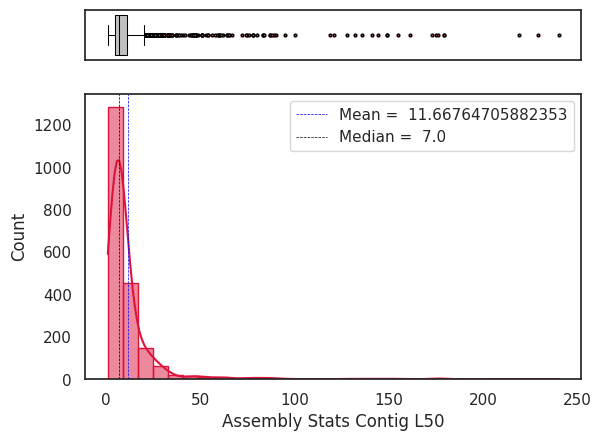

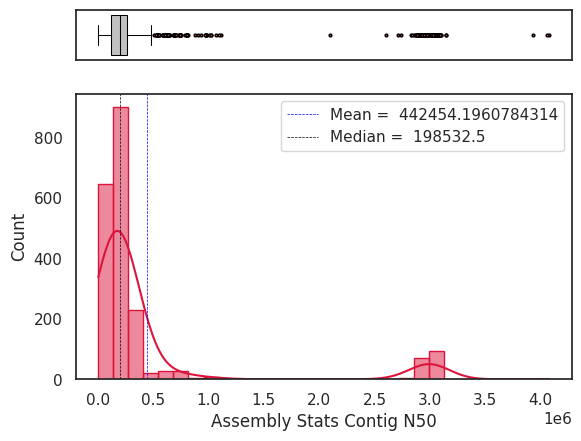

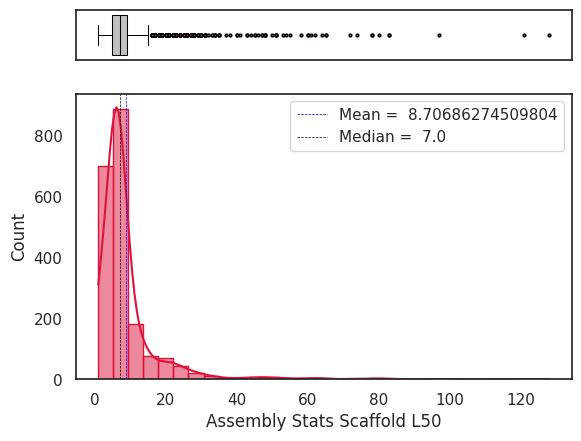

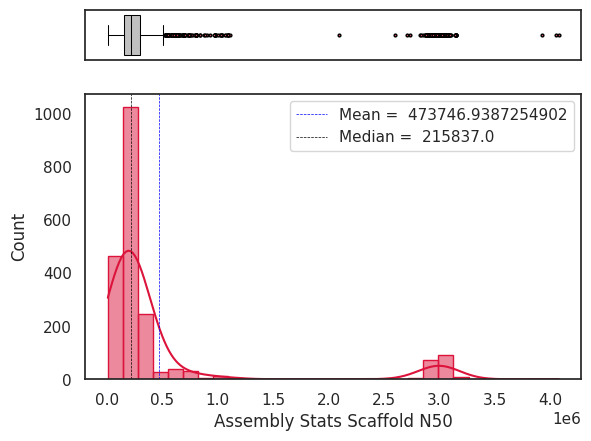

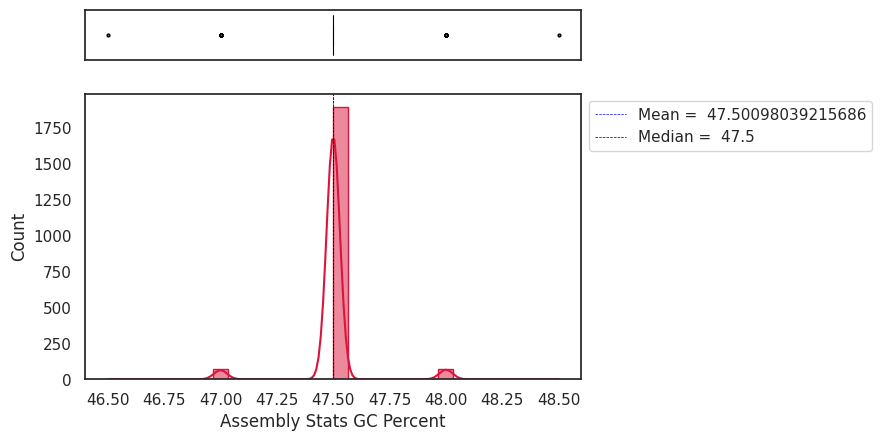

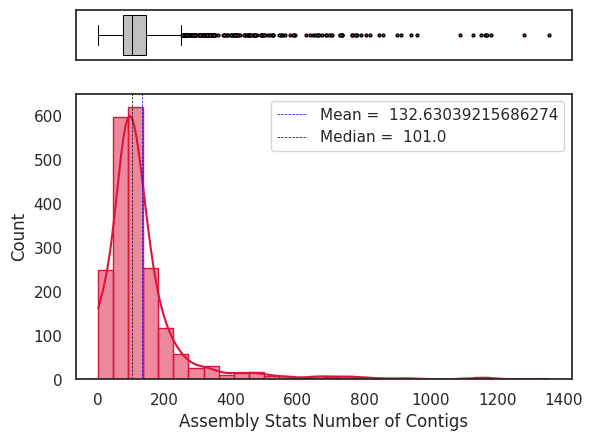

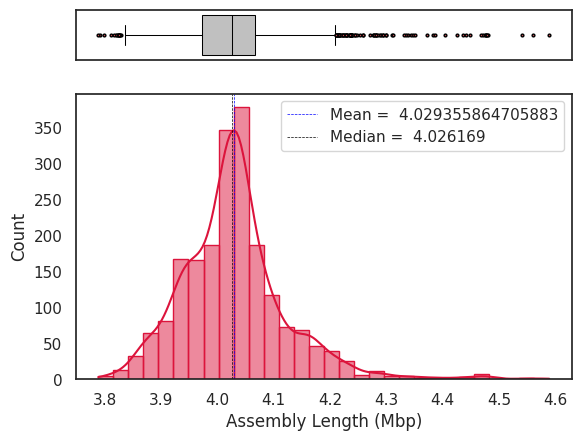

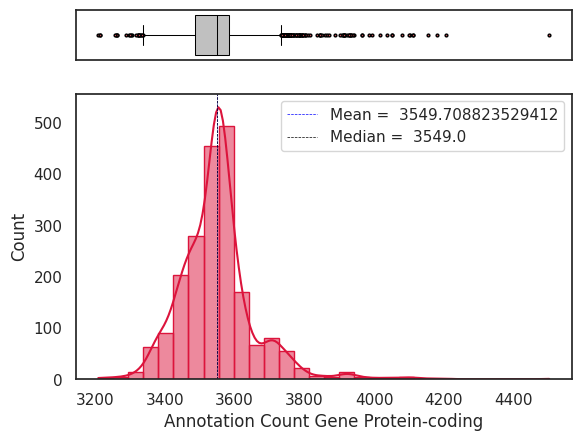

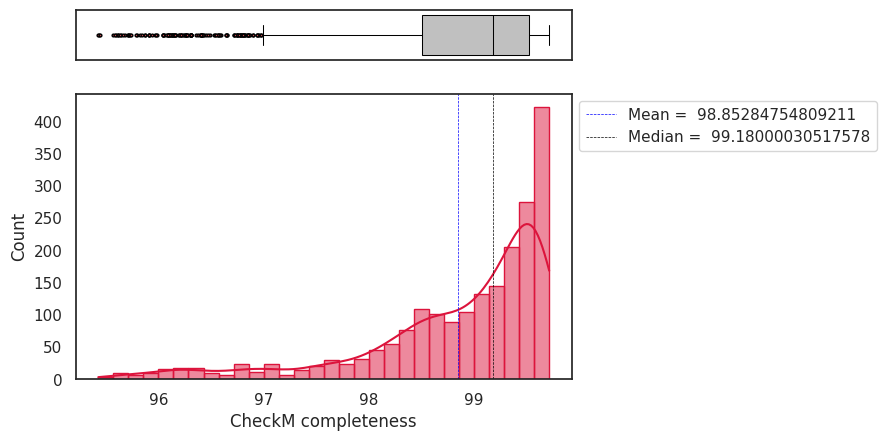

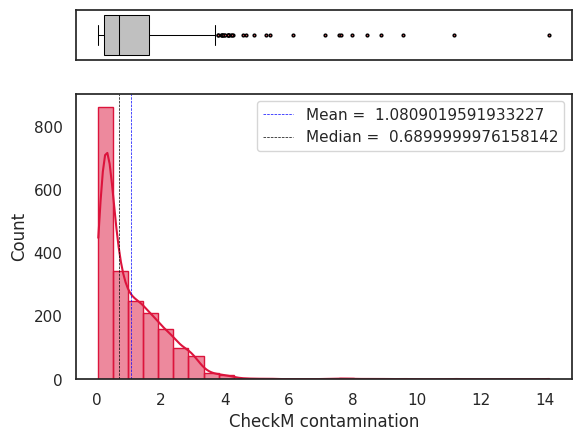

In [144]:
statplot(merg, ["Assembly Stats Contig L50",
                "Assembly Stats Contig N50", 
                'Assembly Stats Scaffold L50',
                'Assembly Stats Scaffold N50',
                "Assembly Stats GC Percent",
                "Assembly Stats Number of Contigs",
                "Assembly Length (Mbp)",
                "Annotation Count Gene Protein-coding",
                "CheckM completeness",
                "CheckM contamination"])

In [145]:
pd.options.display.float_format = '{:.2f}'.format
merg.describe().T

,count,mean,std,min,25%,50%,75%,max
Annotation Count Gene Non-coding,2040.00,90.79,23.69,18.00,76.00,88.00,108.00,167.00
Annotation Count Gene Protein-coding,2040.00,3549.71,109.33,3209.00,3486.00,3549.00,3585.00,4502.00
Annotation Count Gene Pseudogene,2040.00,75.24,38.53,24.00,52.00,64.00,87.00,437.00
Annotation Count Gene Total,2040.00,3715.74,128.35,3376.00,3650.00,3705.00,3761.00,4849.00
Assembly Stats ATGC Count,2040.00,4026601.86,95372.49,3631844.00,3967904.25,4024350.50,4065074.00,4589433.00
Assembly Stats Contig L50,2040.00,11.67,18.76,1.00,5.00,7.00,11.00,240.00
Assembly Stats Contig N50,2040.00,442454.20,799904.09,5246.00,117869.25,198532.50,268726.75,4077462.00
Assembly Stats GC Count,2040.00,1913259.93,43611.20,1748546.00,1886329.00,1911291.00,1929996.25,2196784.00
Assembly Stats GC Percent,2040.00,47.50,0.14,46.50,47.50,47.50,47.50,48.50
Assembly Stats Number of Component Sequences,2040.00,117.11,111.74,1.00,67.75,95.00,133.00,1356.00


In [146]:
merg.columns

Index(['Assembly Accession', 'Annotation Count Gene Non-coding',
       'Annotation Count Gene Protein-coding',
       'Annotation Count Gene Pseudogene', 'Annotation Count Gene Total',
       'Assembly BioProject Accession',
       'Assembly BioProject Lineage Accession',
       'Assembly BioProject Lineage Title',
       'Assembly BioSample BioProject Accession',
       'Assembly BioSample Geographic location', 'Assembly BioSample Host',
       'Assembly BioSample Host disease',
       'Assembly BioSample Isolation source',
       'Assembly BioSample Latitude and Longitude',
       'Assembly BioSample Serotype', 'Assembly BioSample Serovar',
       'Assembly Level', 'Assembly Type', 'Assembly Stats ATGC Count',
       'Assembly Stats Contig L50', 'Assembly Stats Contig N50',
       'Assembly Stats GC Count', 'Assembly Stats GC Percent',
       'Assembly Stats Genome Coverage',
       'Assembly Stats Number of Component Sequences',
       'Assembly Stats Number of Contigs',
       'As

## threshold checks

In [147]:
# tuple for ogawa and inaba genomes
prefixes = ('O1_Ogawa', 'O1_Inaba')

# starting with either (ogawa,inaba) AND config_no > 300
filtered_df = merg[merg['serogroup_serotype'].str.startswith(prefixes, na=False
                                                            ) & (merg['Assembly Stats Number of Contigs'] > 300)]
filtered_df.serogroup_serotype.value_counts()  # ogawa and inaba genomes with assembly contig number more than 300

serogroup_serotype
O1_Inaba    17
O1_Ogawa    17
Name: count, dtype: int64

In [148]:
(merg[merg['Assembly Stats Number of Contigs'] >= 200]).shape  # genomes with contig number greater than 200

(270, 47)

In [149]:
merg.columns

Index(['Assembly Accession', 'Annotation Count Gene Non-coding',
       'Annotation Count Gene Protein-coding',
       'Annotation Count Gene Pseudogene', 'Annotation Count Gene Total',
       'Assembly BioProject Accession',
       'Assembly BioProject Lineage Accession',
       'Assembly BioProject Lineage Title',
       'Assembly BioSample BioProject Accession',
       'Assembly BioSample Geographic location', 'Assembly BioSample Host',
       'Assembly BioSample Host disease',
       'Assembly BioSample Isolation source',
       'Assembly BioSample Latitude and Longitude',
       'Assembly BioSample Serotype', 'Assembly BioSample Serovar',
       'Assembly Level', 'Assembly Type', 'Assembly Stats ATGC Count',
       'Assembly Stats Contig L50', 'Assembly Stats Contig N50',
       'Assembly Stats GC Count', 'Assembly Stats GC Percent',
       'Assembly Stats Genome Coverage',
       'Assembly Stats Number of Component Sequences',
       'Assembly Stats Number of Contigs',
       'As

In [150]:
# 41 + 6 columns (added during data cleaning and normalisation:
##'collection_year', 'year_bin', 'isolation_source_category',
###'combined_sero', 'serogroup_serotype', 'Assembly Length (Mbp)' )

                    200  250  300   500
serogroup_serotype                     
unkwn               185  117   87 30.00
non_O1               30   17   12  3.00
O1_Inaba             24   18   17 13.00
O1_Ogawa             22   18   17 10.00
O1_unkwn              6    3    3  0.00


(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'unkwn'),
  Text(1, 0, 'non_O1'),
  Text(2, 0, 'O1_Inaba'),
  Text(3, 0, 'O1_Ogawa'),
  Text(4, 0, 'O1_unkwn')])

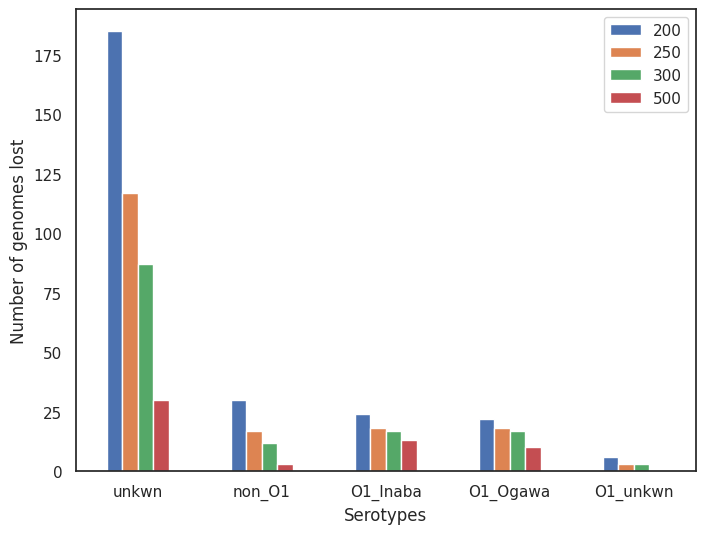

In [151]:
thresholds = [200, 250, 300, 500]

res = pd.DataFrame()

for t in thresholds:  # > [200,250,300,500]
    res[t] = merg[merg['Assembly Stats Number of Contigs'] > t]['serogroup_serotype'].value_counts()
print(res.fillna(0))

res.plot(kind='bar', figsize=(8,6))
plt.ylabel("Number of genomes lost")
plt.xlabel("Serotypes")
plt.xticks(rotation=0)

                     200   250   300   500
serogroup_serotype                        
unkwn               1388  1456  1486  1543
non_O1               116   129   134   143
O1_Ogawa             102   106   107   114
O1_unkwn              84    87    87    90
O1_Inaba              82    88    89    93
O1_Hikoshima           1     1     1     1


(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'unkwn'),
  Text(1, 0, 'non_O1'),
  Text(2, 0, 'O1_Ogawa'),
  Text(3, 0, 'O1_unkwn'),
  Text(4, 0, 'O1_Inaba'),
  Text(5, 0, 'O1_Hikoshima')])

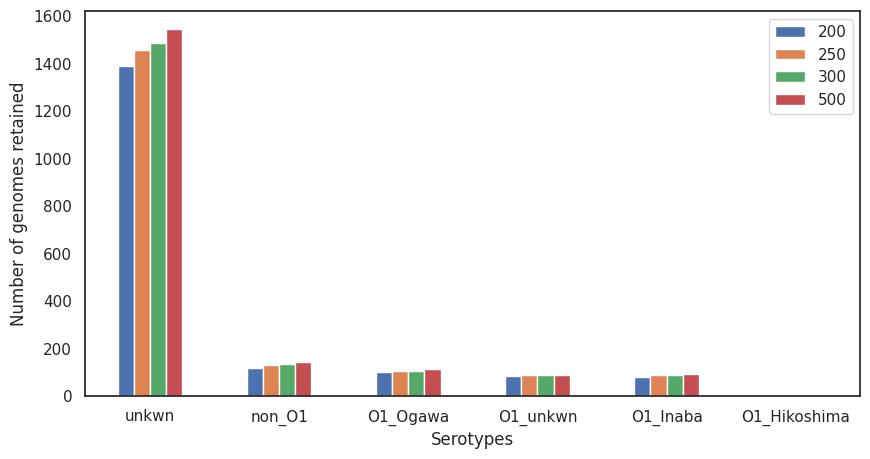

In [152]:
thresholds = [200, 250, 300, 500]

res = pd.DataFrame()

for t in thresholds: # <= [200, 250, 300, 350] 
    res[t] = merg[merg['Assembly Stats Number of Contigs'] <= t]['serogroup_serotype'].value_counts()
print(res.fillna(0))

res.plot(kind='bar', figsize=(10,5))
plt.ylabel("Number of genomes retained")
plt.xlabel("Serotypes")
plt.xticks(rotation=0)

In [153]:
# significant number of genomes will be retained if 250 is used as the threshold (around 1800)
# along with completeness and conatmination
# check - matched with previous results

# Filtering out the necessary columns

In [154]:
merg_before_qc = merg[['Assembly Accession',
                       
                       # metadata columns - info about genome
                       'Assembly BioSample Geographic location',
                       'Assembly BioSample Host',
                       'Assembly BioSample Host disease',
                       'Assembly BioSample Isolation source',
                       'isolation_source_category',
                       'Assembly BioSample Latitude and Longitude',
                       'collection_year',
                       'year_bin',
                       'serogroup_serotype',

                       # genome stats
                       'Assembly Level', 
                       'Assembly Stats Contig L50', 
                       'Assembly Stats Contig N50',
                       'Assembly Stats GC Count', 
                       'Assembly Stats GC Percent',
                       'Assembly Stats Genome Coverage',
                       'Assembly Stats Number of Component Sequences',
                       'Assembly Stats Number of Contigs',
                       'Assembly Stats Number of Scaffolds', 
                       'Assembly Stats Scaffold L50',
                       'Assembly Stats Scaffold N50', 
                       'Assembly Length (Mbp)',
                       'CheckM completeness', 
                       'CheckM contamination' 
                      ]]
                

In [155]:
print("Rows and columns before QC", merg_before_qc.shape)

Rows and columns before QC (2040, 24)


# Filtering low quality genomes (based on assembly stats)

In [156]:
merg_filt = merg_before_qc[
    (merg_before_qc['CheckM completeness'] >= 95) &
    (merg_before_qc['CheckM contamination'] <= 5) &
    (merg_before_qc['Assembly Stats Number of Contigs'] < 250)]

In [157]:
pd.options.display.float_format = '{:.2f}'.format
merg_filt.describe().T

,count,mean,std,min,25%,50%,75%,max
Assembly Stats Contig L50,1866.00,8.42,6.03,1.00,5.00,7.00,10.00,35.00
Assembly Stats Contig N50,1866.00,474668.20,828316.29,32032.00,130400.50,207147.50,283078.00,4077462.00
Assembly Stats GC Count,1866.00,1912390.45,39744.05,1753892.00,1887579.00,1911278.50,1928109.25,2145143.00
Assembly Stats GC Percent,1866.00,47.50,0.12,46.50,47.50,47.50,47.50,48.00
Assembly Stats Number of Component Sequences,1866.00,94.76,52.58,1.00,65.00,92.00,123.00,249.00
Assembly Stats Number of Contigs,1866.00,99.96,54.16,1.00,71.00,97.00,130.00,249.00
Assembly Stats Number of Scaffolds,1866.00,92.70,50.95,1.00,64.00,90.00,120.00,249.00
Assembly Stats Scaffold L50,1866.00,7.40,5.26,1.00,5.00,6.00,8.00,35.00
Assembly Stats Scaffold N50,1866.00,500039.39,828010.32,32032.00,162322.00,227725.50,301222.25,4077462.00
Assembly Length (Mbp),1866.00,4.03,0.09,3.79,3.97,4.03,4.06,4.54


In [160]:
# check - matched with the previous result

## serotype distribution before and after QC

In [159]:
print("Before QC")
print(merg_before_qc['serogroup_serotype'].value_counts())

print("\nAfter QC")
print(merg_filt['serogroup_serotype'].value_counts())

Before QC
serogroup_serotype
unkwn           1573
non_O1           146
O1_Ogawa         124
O1_Inaba         106
O1_unkwn          90
O1_Hikoshima       1
Name: count, dtype: int64

After QC
serogroup_serotype
unkwn           1455
non_O1           129
O1_Ogawa         106
O1_Inaba          88
O1_unkwn          87
O1_Hikoshima       1
Name: count, dtype: int64


In [161]:
before = merg_before_qc['serogroup_serotype'].value_counts(normalize=True)
after = merg_filt['serogroup_serotype'].value_counts(normalize=True)

compare = pd.concat([before, after], axis=1, keys=['Before QC', 'After QC'])
compare

,Before QC,After QC
serogroup_serotype,,
unkwn,0.77,0.78
non_O1,0.07,0.07
O1_Ogawa,0.06,0.06
O1_Inaba,0.05,0.05
O1_unkwn,0.04,0.05
O1_Hikoshima,0.00,0.00


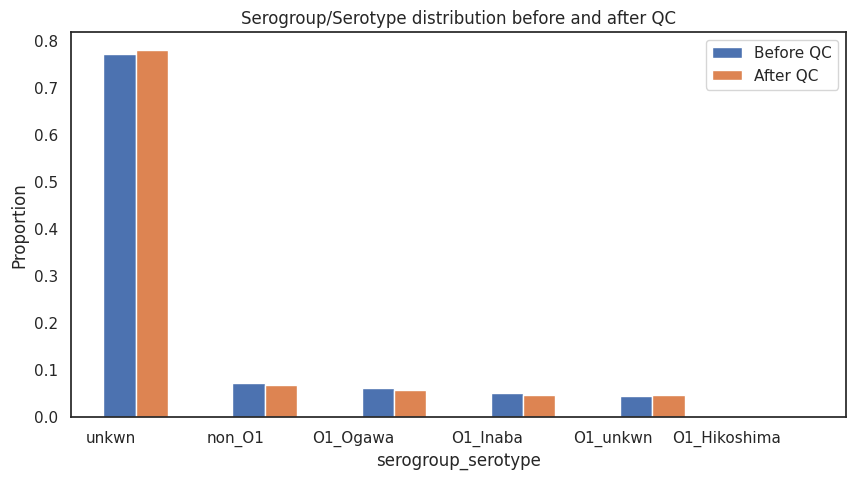

In [162]:
compare[['Before QC', 'After QC']].plot(kind='bar', figsize=(10,5))
plt.xticks(rotation=0, ha='right')
plt.ylabel("Proportion")
plt.title("Serogroup/Serotype distribution before and after QC")
plt.show()

In [163]:
# check - matched with the previous result

# Providing sample_ids

In [164]:
sample_ids = []
for i in range(len(merg_filt)):
    sample_ids.append(f"VC_{str(i+1).zfill(4)}")

merg_filt.insert(0, "Sample_ID", sample_ids)

In [165]:
merg_filt

,Sample_ID,Assembly Accession,Assembly BioSample Geographic location,Assembly BioSample Host,Assembly BioSample Host disease,Assembly BioSample Isolation source,isolation_source_category,Assembly BioSample Latitude and Longitude,collection_year,year_bin,serogroup_serotype,Assembly Level,Assembly Stats Contig L50,Assembly Stats Contig N50,Assembly Stats GC Count,Assembly Stats GC Percent,Assembly Stats Genome Coverage,Assembly Stats Number of Component Sequences,Assembly Stats Number of Contigs,Assembly Stats Number of Scaffolds,Assembly Stats Scaffold L50,Assembly Stats Scaffold N50,Assembly Length (Mbp),CheckM completeness,CheckM contamination
0,VC_0001,GCF_000736765.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1973,1973–1991,non_O1,Contig,12,116343,1847732,48.00,51.90,118,118,118,12,116343,3.87,98.41,1.23
7,VC_0002,GCF_000736775.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1981,1973–1991,non_O1,Contig,9,145570,1883900,47.50,46.80,117,117,117,9,145570,3.95,98.29,1.16
14,VC_0003,GCF_000736785.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1977,1973–1991,non_O1,Contig,10,153084,1881066,47.50,26.90,118,118,118,10,153084,3.97,98.14,1.28
21,VC_0004,GCF_000736795.1,Philippines,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1962,1961–1972,non_O1,Contig,9,154399,1864238,47.50,25.60,94,94,94,9,154399,3.91,98.04,0.35
28,VC_0005,GCF_000736845.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1992,1992–2025,non_O1,Contig,6,246082,1909432,47.50,44.70,81,81,81,6,246082,4.02,98.59,0.24
35,VC_0006,GCF_000736855.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1969,1961–1972,non_O1,Contig,13,103518,1893297,47.50,25.50,130,130,130,13,103518,3.97,98.70,0.80
42,VC_0007,GCF_000736865.1,India,unkwn,unkwn,unkwn,unkwn,unkwn,1941,1924–1960,O1_Ogawa,Contig,7,197662,1876549,47.50,45.40,111,111,111,7,197662,3.95,99.60,0.24
48,VC_0008,GCF_000736875.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1974,1973–1991,unkwn,Contig,14,80785,1910069,47.50,49.60,151,151,151,14,80785,4.01,98.76,1.17
54,VC_0009,GCF_000736925.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1975,1973–1991,non_O1,Contig,9,152166,1914076,47.50,39.70,152,152,152,9,152166,4.03,98.65,0.24
61,VC_0010,GCF_000736935.1,India,Human hosts,unkwn,Clinical sample,Clinical sample,unkwn,1976,1973–1991,non_O1,Contig,10,132017,1939025,47.50,40.40,82,82,82,10,132017,4.07,99.02,1.17


In [171]:
merg_filt.to_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")

# EDA

In [172]:
merg_filt = pd.read_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")

## bar plots

In [173]:
def bar_counts(df, col):
    ax = df[col].value_counts().plot(
        kind="bar",
        color="lightblue",
        edgecolor="black",
        figsize=(6, 4)
    )
    
    for p in ax.patches:
        ax.annotate(int(p.get_height()),
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha="center",va="bottom",fontsize=7, fontweight="bold")
    
    plt.xlabel(col)
    plt.ylabel("Count", fontsize=9)
    plt.title(col, fontsize=10)
    
    plt.xticks(rotation=45, ha="right", fontsize=8, fontweight="bold")
    plt.yticks(fontsize=8, fontweight="bold")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [174]:
merg_filt.columns

Index(['Unnamed: 0', 'Sample_ID', 'Assembly Accession',
       'Assembly BioSample Geographic location', 'Assembly BioSample Host',
       'Assembly BioSample Host disease',
       'Assembly BioSample Isolation source', 'isolation_source_category',
       'Assembly BioSample Latitude and Longitude', 'collection_year',
       'year_bin', 'serogroup_serotype', 'Assembly Level',
       'Assembly Stats Contig L50', 'Assembly Stats Contig N50',
       'Assembly Stats GC Count', 'Assembly Stats GC Percent',
       'Assembly Stats Genome Coverage',
       'Assembly Stats Number of Component Sequences',
       'Assembly Stats Number of Contigs',
       'Assembly Stats Number of Scaffolds', 'Assembly Stats Scaffold L50',
       'Assembly Stats Scaffold N50', 'Assembly Length (Mbp)',
       'CheckM completeness', 'CheckM contamination'],
      dtype='str')

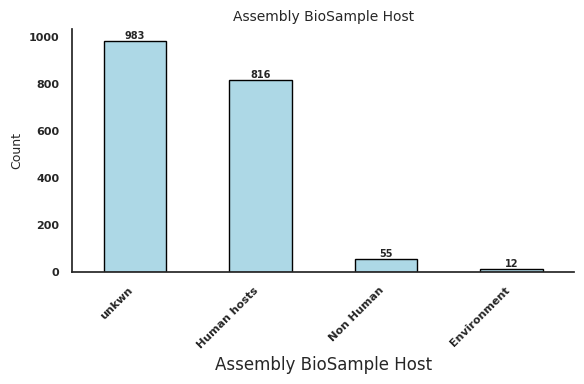

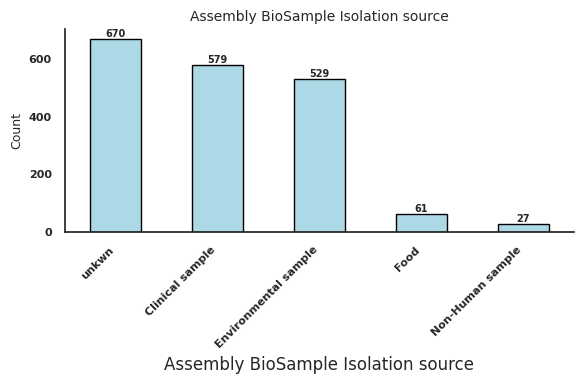

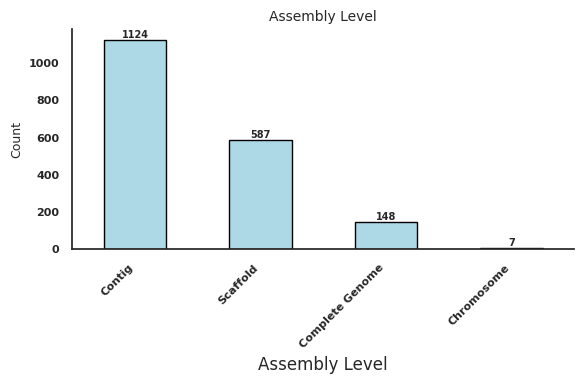

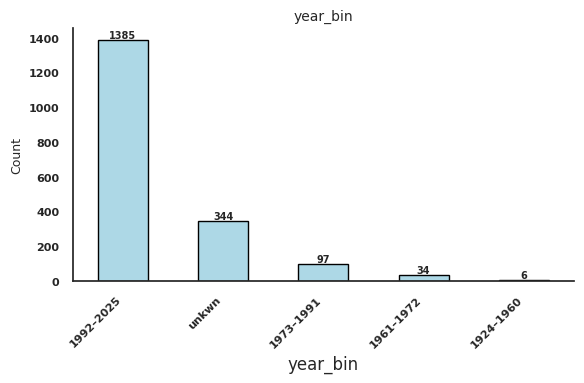

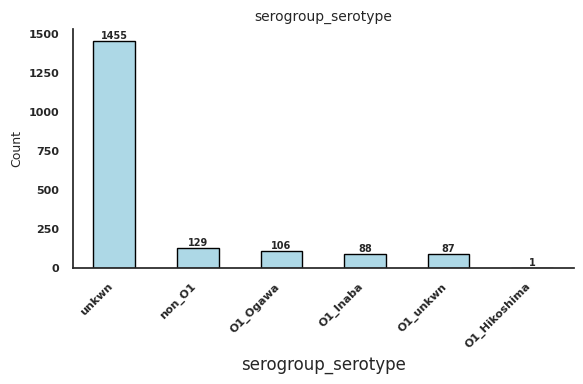

In [176]:
cols = ['Assembly BioSample Host', 
        'Assembly BioSample Isolation source',
        'Assembly Level',
        'year_bin', 
        'serogroup_serotype']
        
for col in cols:
    bar_counts(merg_filt, col)

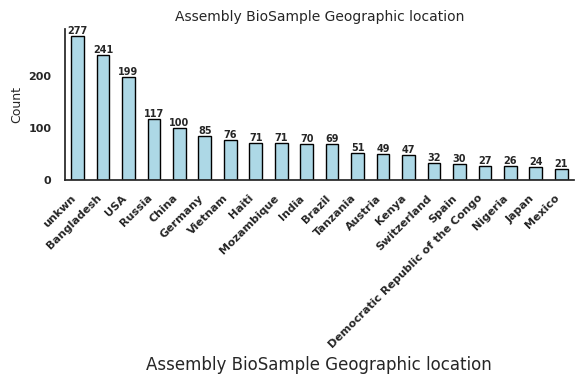

In [177]:
col = 'Assembly BioSample Geographic location'
bar_counts(merg_filt[merg_filt[col].isin(merg_filt[col].value_counts().head(20).index)], col)

## heatmaps

In [178]:
def heatmap(df, row_col, col_col, top_n=20):
    
    top = df[row_col].value_counts().head(top_n).index
    d = df[df[row_col].isin(top)]
    
    heat = d.groupby([row_col, col_col]).size().unstack(fill_value=0)
    heat = heat.sort_index(axis=1)
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(heat,cmap='RdPu',linewidths=0.5,     linecolor='white',cbar_kws={'label': 'Count'})
    plt.xlabel(col_col, fontsize=10, fontweight='bold')
    plt.ylabel(row_col, fontsize=10, fontweight='bold')
    plt.xticks(rotation=0, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.title(f"{row_col} vs {col_col}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

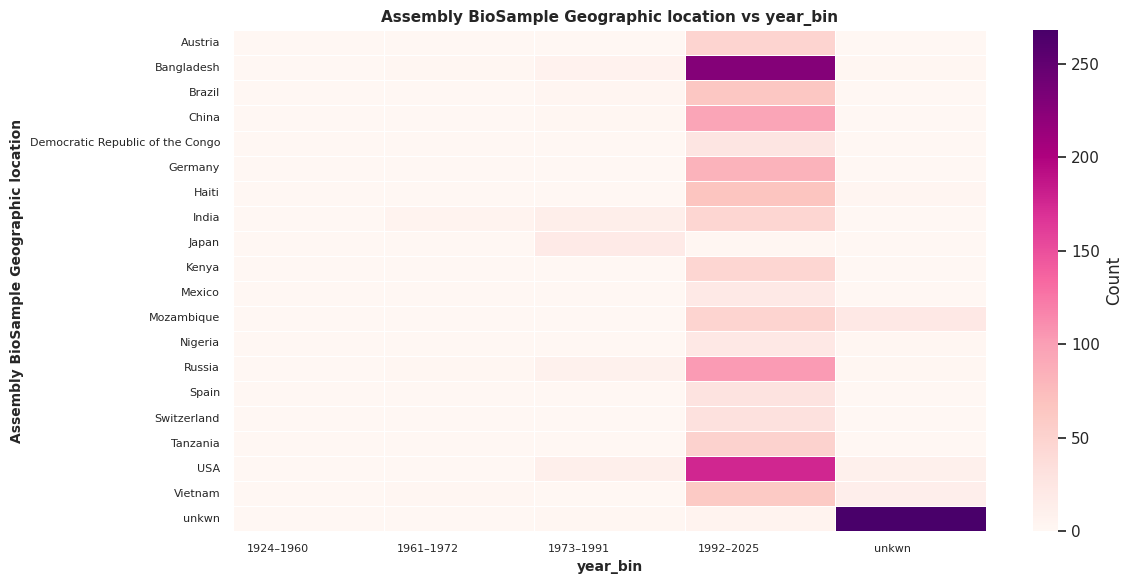

In [179]:
heatmap(merg_filt, 'Assembly BioSample Geographic location', 'year_bin')

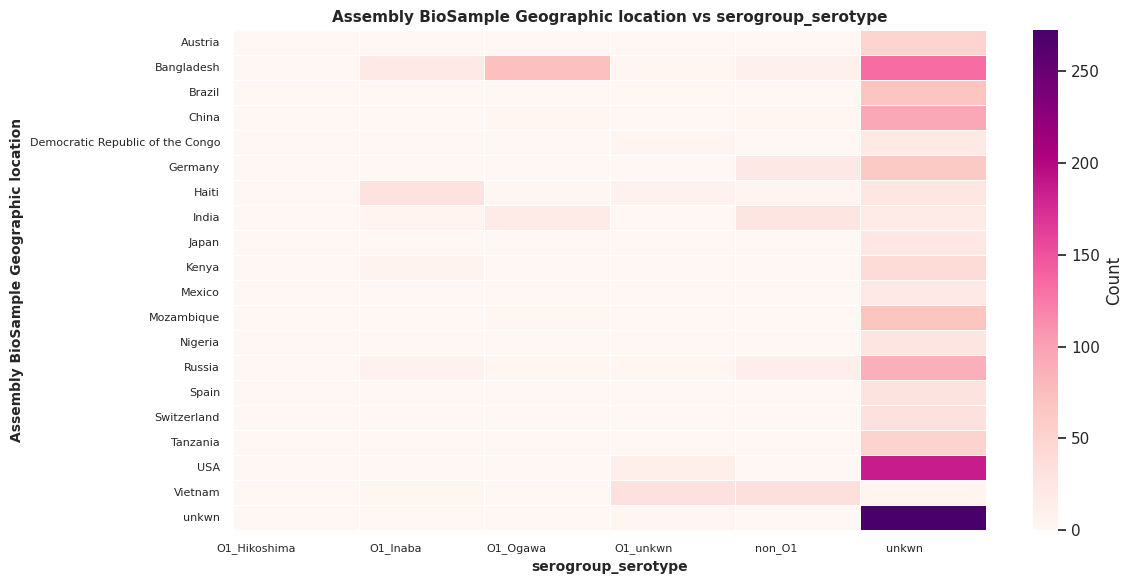

In [180]:
heatmap(merg_filt, 'Assembly BioSample Geographic location', 'serogroup_serotype')

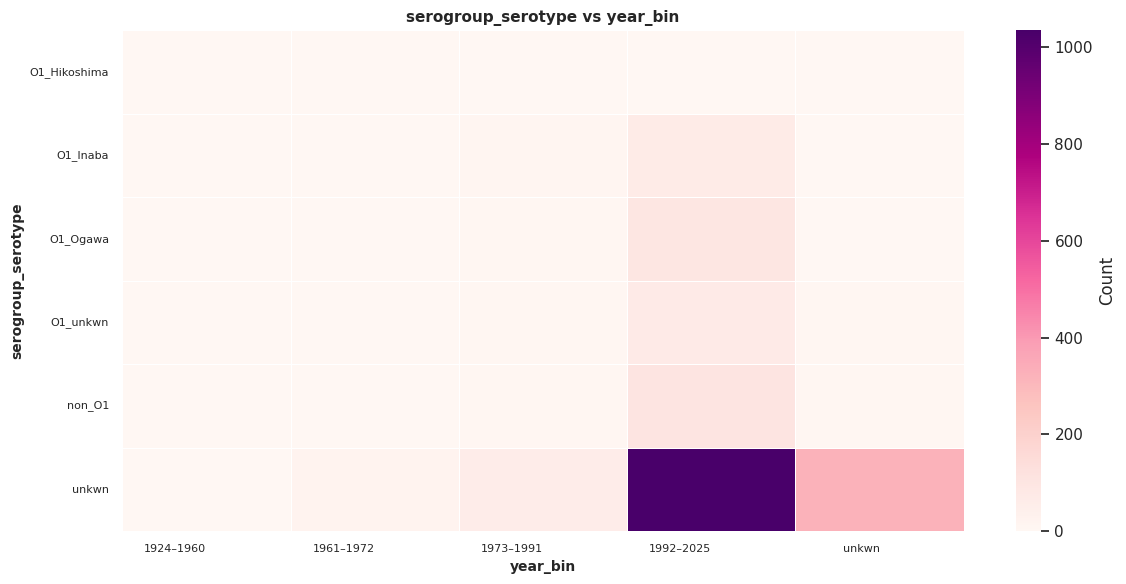

In [181]:
heatmap(merg_filt, 'serogroup_serotype','year_bin')

## Genome statistics

In [182]:
merg_filt.columns

Index(['Unnamed: 0', 'Sample_ID', 'Assembly Accession',
       'Assembly BioSample Geographic location', 'Assembly BioSample Host',
       'Assembly BioSample Host disease',
       'Assembly BioSample Isolation source', 'isolation_source_category',
       'Assembly BioSample Latitude and Longitude', 'collection_year',
       'year_bin', 'serogroup_serotype', 'Assembly Level',
       'Assembly Stats Contig L50', 'Assembly Stats Contig N50',
       'Assembly Stats GC Count', 'Assembly Stats GC Percent',
       'Assembly Stats Genome Coverage',
       'Assembly Stats Number of Component Sequences',
       'Assembly Stats Number of Contigs',
       'Assembly Stats Number of Scaffolds', 'Assembly Stats Scaffold L50',
       'Assembly Stats Scaffold N50', 'Assembly Length (Mbp)',
       'CheckM completeness', 'CheckM contamination'],
      dtype='str')

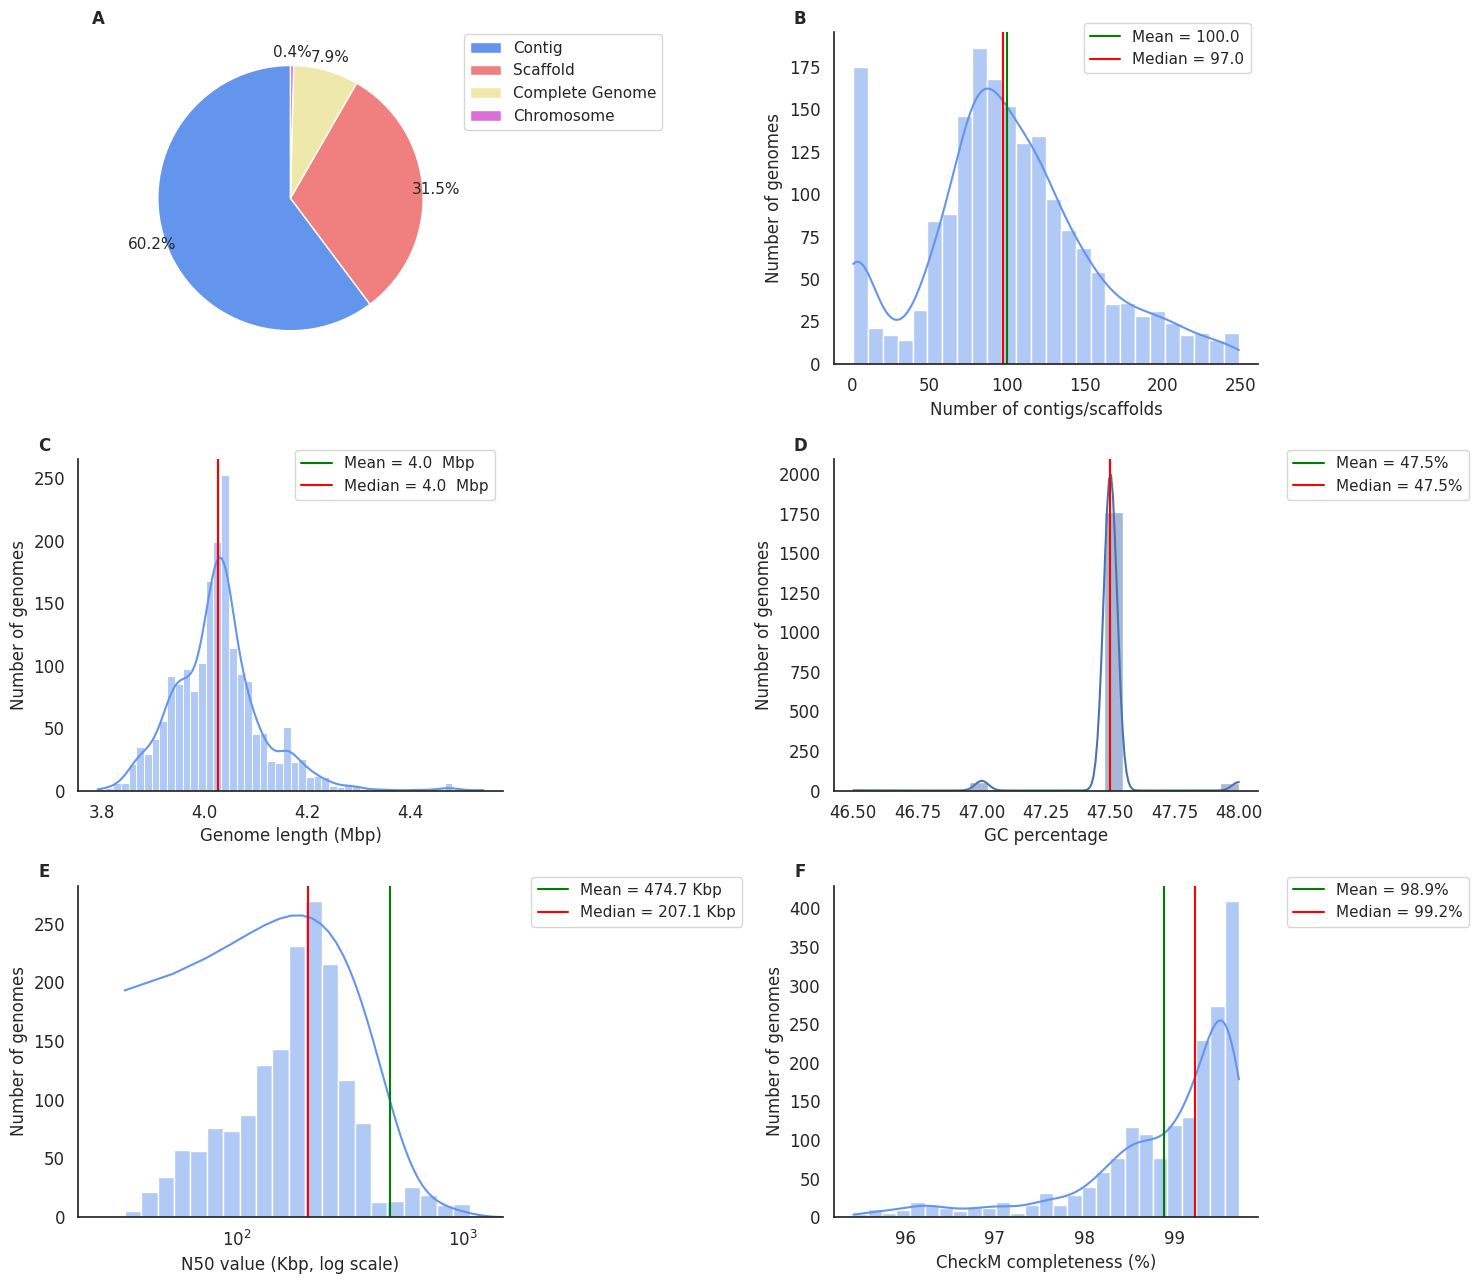

In [186]:
fig, ax = plt.subplots(3, 2, figsize=(15, 13))
custom_colors = ["cornflowerblue", "lightcoral",'palegoldenrod','orchid']  

# Pie chart
assembly_counts = merg_filt['Assembly Level'].value_counts()
explode = [0] * len(assembly_counts)

wedges, texts, autotexts = ax[0,0].pie(
    assembly_counts,
    explode=explode,
    labels=None,
    autopct='%1.1f%%',
    pctdistance=1.1,
    colors=custom_colors[:len(assembly_counts)],
    startangle=90,
    textprops={'fontsize': 11}
)

## legend 
ax[0,0].legend(wedges, assembly_counts.index,loc="center left",
               bbox_to_anchor=(1, 0.35, 0.5, 1),fontsize=11)
ax[0,0].set_title('A', fontsize = 12, fontweight="bold", x=-0.08)



#contigs distribution
contigs =  merg_filt["Assembly Stats Number of Contigs"]
mean_contig = np.mean(contigs)
median_contig = np.median(contigs)

sns.histplot(contigs, ax=ax[0,1], kde=True, color="cornflowerblue")
ax[0,1].axvline(mean_contig, color='green', label=f'Mean = {mean_contig:.1f}')
ax[0,1].axvline(median_contig, color='red', label=f'Median = {median_contig:.1f}')
ax[0,1].set_xlabel("Number of contigs/scaffolds", fontsize=12)
ax[0,1].set_ylabel("Number of genomes", fontsize=12)
ax[0,1].tick_params(axis='both', labelsize=12)
ax[0,1].legend(bbox_to_anchor=(1, 1.05), fontsize=11)
ax[0,1].set_title('B', fontsize = 12, fontweight="bold", x=-0.08)
sns.despine()

#length distribution
length =  merg_filt["Assembly Length (Mbp)"]
mean_length = np.mean(length)
median_length = np.median(length)

sns.histplot(length, ax=ax[1,0], kde=True, color="cornflowerblue")
ax[1,0].axvline(mean_length, color='green', label=f'Mean = {mean_length:.1f}  Mbp')
ax[1,0].axvline(median_length, color='red', label=f'Median = {median_length:.1f}  Mbp')
ax[1,0].set_xlabel("Genome length (Mbp)", fontsize=12)
ax[1,0].set_ylabel("Number of genomes", fontsize=12)
ax[1,0].tick_params(axis='both', labelsize=12)
ax[1,0].legend(bbox_to_anchor=(1, 1.05), fontsize=11)
ax[1,0].set_title('C', fontsize = 12, fontweight="bold", x=-0.08)
sns.despine()


#gc distribution
gc =  merg_filt["Assembly Stats GC Percent"]
mean_gc = np.mean(gc)
median_gc = np.median(gc)

sns.histplot(gc, bins=20, ax=ax[1,1], kde=True)
ax[1,1].axvline(mean_gc, color='green', label=f'Mean = {mean_gc:.1f}%')
ax[1,1].axvline(median_gc, color='red', label=f'Median = {median_gc:.1f}%')
ax[1,1].set_xlabel("GC percentage", fontsize=12)
ax[1,1].set_ylabel("Number of genomes", fontsize=12)
ax[1,1].tick_params(axis='both', labelsize=12)
ax[1,1].legend(bbox_to_anchor=(1.05, 1.05), fontsize=11)
ax[1,1].set_title('D', fontsize = 12, fontweight="bold", x=-0.08)
sns.despine()

#N50 distribution
N50 =  merg_filt["Assembly Stats Contig N50"]/ 1000
mean_N50 = np.mean(N50)
median_N50 = np.median(N50)

bins = np.logspace(np.log10(N50.min()),np.log10(N50.max()),30)
sns.histplot(N50, bins = bins, ax=ax[2,0], kde=True, color="cornflowerblue", linewidth = 1.0)
ax[2,0].set_xscale("log") #log axis
ax[2,0].set_xlim(20, 1500)
ax[2,0].axvline(mean_N50, color='green', label=f'Mean = {mean_N50:.1f} Kbp')
ax[2,0].axvline(median_N50, color='red', label=f'Median = {median_N50:.1f} Kbp')
ax[2,0].set_xlabel("N50 value (Kbp, log scale)", fontsize=12)
ax[2,0].set_ylabel("Number of genomes", fontsize=12)
ax[2,0].tick_params(axis='both', labelsize=12)
ax[2,0].legend(bbox_to_anchor=(1.05, 1.05), fontsize=11)
ax[2,0].set_title('E', fontsize = 12, fontweight="bold", x=-0.08)
sns.despine()

#Completeness
checkm = merg_filt["CheckM completeness"]
mean_checkm = np.mean(checkm)
median_checkm = np.median(checkm)
sns.histplot(checkm, ax=ax[2,1], kde=True, color="cornflowerblue")

ax[2,1].axvline(mean_checkm,color='green',label=f'Mean = {mean_checkm:.1f}%')
ax[2,1].axvline(median_checkm,color='red',label=f'Median = {median_checkm:.1f}%')
ax[2,1].set_xlabel("CheckM completeness (%)", fontsize=12)
ax[2,1].set_ylabel("Number of genomes", fontsize=12)
ax[2,1].tick_params(axis='both', labelsize=12)
ax[2,1].legend(bbox_to_anchor=(1.05, 1.05), fontsize=11)
ax[2,1].set_title('F', x=-0.08,fontsize=12,fontweight='bold')

plt.tight_layout()
#plt.show()
#plt.savefig("Assembly_stat_vis.tiff", dpi = 300, bbox_inches="tight")

In [187]:
merg_filt.describe()

,Unnamed: 0,Assembly Stats Contig L50,Assembly Stats Contig N50,Assembly Stats GC Count,Assembly Stats GC Percent,Assembly Stats Number of Component Sequences,Assembly Stats Number of Contigs,Assembly Stats Number of Scaffolds,Assembly Stats Scaffold L50,Assembly Stats Scaffold N50,Assembly Length (Mbp),CheckM completeness,CheckM contamination
count,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00,1866.00
mean,9846.11,8.42,474668.20,1912390.45,47.50,94.76,99.96,92.70,7.40,500039.39,4.03,98.89,0.99
std,5060.85,6.03,828316.29,39744.05,0.12,52.58,54.16,50.95,5.26,828010.32,0.09,0.89,0.88
min,0.00,1.00,32032.00,1753892.00,46.50,1.00,1.00,1.00,1.00,32032.00,3.79,95.42,0.10
25%,5717.50,5.00,130400.50,1887579.00,47.50,65.00,71.00,64.00,5.00,162322.00,3.97,98.53,0.24
50%,9719.00,7.00,207147.50,1911278.50,47.50,92.00,97.00,90.00,6.00,227725.50,4.03,99.23,0.64
75%,14164.50,10.00,283078.00,1928109.25,47.50,123.00,130.00,120.00,8.00,301222.25,4.06,99.53,1.52
max,19563.00,35.00,4077462.00,2145143.00,48.00,249.00,249.00,249.00,35.00,4077462.00,4.54,99.72,4.91


In [188]:
# check - matches the previous result

# Filtering fna files

In [189]:
df = pd.read_csv("/media/dell/My Passport/vc_files_v_final/1_data_curation/metadata_filtered.csv")

assembly_ids = df["Assembly Accession"]

# file from ncbi cli
o_dir = "/media/dell/My Passport/v_cholerae_hierarchial_ml/all_files/0_files_retrieved/0_data/v_cholerae_dataset/ncbi_dataset/data"

f_dir = "/media/dell/My Passport/vc_files_v_final/1_data_curation/filtered"

os.makedirs(f_dir, exist_ok=True)

for acc in df["Assembly Accession"]:
    folder = os.path.join(o_dir, acc)

    if os.path.exists(folder):
        for file in os.listdir(folder):
            if file.endswith(".fna"):
                os.system(f'cp "{os.path.join(folder, file)}" "{f_dir}/"')
    else:
        print("Missing:", acc)

In [190]:
df[["Assembly Accession", "Sample_ID"]]

,Assembly Accession,Sample_ID
0,GCF_000736765.1,VC_0001
1,GCF_000736775.1,VC_0002
2,GCF_000736785.1,VC_0003
3,GCF_000736795.1,VC_0004
4,GCF_000736845.1,VC_0005
5,GCF_000736855.1,VC_0006
6,GCF_000736865.1,VC_0007
7,GCF_000736875.1,VC_0008
8,GCF_000736925.1,VC_0009
9,GCF_000736935.1,VC_0010


In [191]:
f_dir = "/media/dell/My Passport/vc_files_v_final/1_data_curation/filtered"

files = os.listdir(f_dir)

for _, row in df.iterrows():
    acc = row["Assembly Accession"]
    sample = row["Sample_ID"]

    found = False

    for file in files:
        if acc in file and file.endswith(".fna"):
            old_path = os.path.join(f_dir, file)
            new_path = os.path.join(f_dir, f"{sample}.fna")
            print(f"{file}  -->  {sample}.fna")
            os.rename(old_path, new_path)
            found = True
            break

GCF_000736765.1_GFC_10_genomic.fna  -->  VC_0001.fna
GCF_000736775.1_GFC_15_genomic.fna  -->  VC_0002.fna
GCF_000736785.1_GFC_14_genomic.fna  -->  VC_0003.fna
GCF_000736795.1_GFC_8_genomic.fna  -->  VC_0004.fna
GCF_000736845.1_GFC_18_genomic.fna  -->  VC_0005.fna
GCF_000736855.1_GFC_9_genomic.fna  -->  VC_0006.fna
GCF_000736865.1_GFC_7_genomic.fna  -->  VC_0007.fna
GCF_000736875.1_GFC_11_genomic.fna  -->  VC_0008.fna
GCF_000736925.1_GFC_12_genomic.fna  -->  VC_0009.fna
GCF_000736935.1_GFC_13_genomic.fna  -->  VC_0010.fna
GCF_000736945.1_GFC_16_genomic.fna  -->  VC_0011.fna
GCF_000737005.1_GFC_19_genomic.fna  -->  VC_0012.fna
GCF_000737025.1_GFC_20_genomic.fna  -->  VC_0013.fna
GCF_000765415.1_ASM76541v1_genomic.fna  -->  VC_0014.fna
GCF_000788415.1_ASM78841v1_genomic.fna  -->  VC_0015.fna
GCF_000788425.1_ASM78842v1_genomic.fna  -->  VC_0016.fna
GCF_000788435.1_ASM78843v1_genomic.fna  -->  VC_0017.fna
GCF_000788495.1_ASM78849v1_genomic.fna  -->  VC_0018.fna
GCF_000788515.1_ASM78851v1_ge